### DSC 106 Project 2
Dataset Information: The Guttmacher Institute is a research and policy organization committed to advancing sexual and reproductive health and rights. They maintain a variety of global data related to global reproductive rights. This data set contains data about abortion rates, abortion providers, and abortion seekers, aggregated to the state level.



In [16]:
! pip install openpyxl

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [18]:
df = pd.read_excel('GuttmacherInstituteAbortionDataByState.xlsx')
df

,U.S. State,"% change in abortion rate, 2017-2020","% change in the no. of abortion clinics, 2017-2020","% change in the no. of abortion providers, 2014-2017","% of all U.S. abortions, by state of occurrence, 2020","% of counties without a known abortion provider, 2014","% of counties without a known clinic, 2020","% of residents obtaining abortions who traveled out of state for care, 2020","% of women aged 15-44 living in a county without a clinic, 2020","% of women aged 15-44 living in a county without an abortion provider, 2014",...,"No. of abortions per 1,000 women aged 15–44, by state of occurrence, 2020","No. of abortions per 1,000 women aged 15–44, by state of residence, 2020","No. of abortions, by state of occurrence, 2020","No. of abortions, by state of residence, 2020","No. of federally funded abortions, 2010","No. of state funded abortions, 2010","Reported public expenditures for abortions (in 000s of dollars), federal, 2015","Reported public expenditures for abortions (in 000s of dollars), state, 2015","Total no. of publicly funded abortions , 2010","Total reported public expenditures for abortions (in 000s of dollars), 2015"
0,Alabama,-6,0,-22,0.6,91,93,47,59,58,...,6.0,9.5,5700,9060,9,0,22,0,9,22
1,Alaska,0,0,-25,0.1,79,87,7,33,17,...,8.6,9.2,1240,1320,0,835,0,216,835,216
2,Arizona,1,0,-8,1.4,80,80,6,18,19,...,9.3,9.7,13320,13820,1,13,28,11,14,40
3,Arkansas,2,-33,0,0.3,97,99,37,86,77,...,5.6,7.8,3250,4510,0,0,0,0,0,0
4,California,17,7,-18,16.6,24,38,0,3,1,...,19.2,19.0,154060,152400,0,88466,0,32613,88466,32613
5,Colorado,3,28,-11,1.4,77,77,1,26,17,...,11.2,9.9,13420,11830,0,0,0,0,0,0
6,Connecticut,-6,-23,-8,1.2,13,0,6,0,5,...,16.7,17.1,11170,11460,0,unavailable,0,184,unavailable,184
7,Delaware,-5,-25,0,0.2,33,33,44,19,18,...,10.0,15.8,1830,2870,1,unavailable,"<1,000",0,1,"<1,000"
8,District of Columbia,62,0,-11,1.0,0,0,45,0,0,...,48.9,26.1,9410,5010,0,0,0,0,0,nr
9,Florida,6,-11,-1,8.3,67,75,1,25,19,...,19.7,18.8,77400,73830,0,unavailable,0,0,unavailable,0


Once you feel like you’ve developed an understanding of the data, devise a proposition about it: a statement that asserts a judgement or opinion about the trends you might have uncovered. 
- An example of a proposition might be “Gun deaths spiked after Florida enacted its ‘Stand Your Ground’ law.”

<Axes: xlabel='U.S. State'>

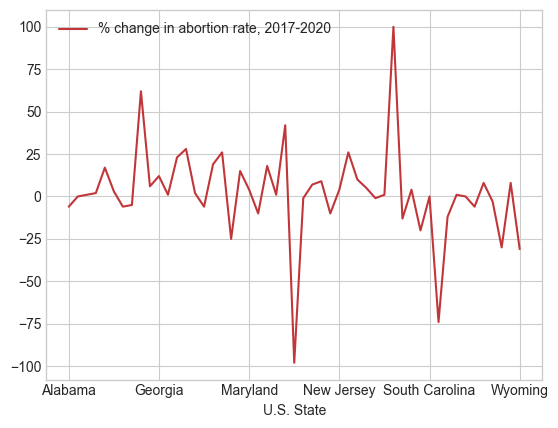

In [19]:
df.plot('U.S. State', '% change in abortion rate, 2017-2020')

In [20]:
df.columns

Index(['U.S. State', '% change in abortion rate, 2017-2020',
       '% change in the no. of abortion clinics, 2017-2020',
       '% change in the no. of abortion providers, 2014-2017',
       '% of all U.S. abortions, by state of occurrence, 2020',
       '% of counties without a known abortion provider, 2014',
       '% of counties without a known clinic, 2020',
       '% of residents obtaining abortions who traveled out of state for care, 2020',
       '% of women aged 15-44 living in a county without a clinic, 2020',
       '% of women aged 15-44 living in a county without an abortion provider, 2014',
       'Abortion rate (the no. of abortions per 1,000 women aged 15-17), by state of residence, 2017',
       'Abortion rate (the no. of abortions per 1,000 women aged 15-19), by state of residence, 2017',
       'Abortion rate (the no. of abortions per 1,000 women aged 18-19), by state of residence, 2017',
       'Change in the no. of abortion clinics, 2017-2020',
       'Change in th

2014: bannng early abortion (frist trimester) and second trimester
2019: alabama enacts a near-total ban on abortion (the alabama legislation)
2019: states have adopted 37 new restrictions on abortion rights and acess
2018: 15 states enact 23 new abortion restrictions (15 week abortion ban in mississppi and 6 week ban in iowa)
2017: president trump reinstates and expands the global gag rule almost immediately after taking office (severely restricting access to reproductive health care abroad, and endangering the health of millions of women in developing countries)

In [ ]:
# Converting the columns to numeric
cols_to_convert = [
    'No. of abortions among women aged 15-17, by state of residence, 2017',
    'No. of abortions among women aged 15-19, by state of residence, 2017',
    'No. of abortions among women aged 18-19, by state of residence, 2017'
]

# Convert the columns to numeric, coercing errors to NaN
df[cols_to_convert] = df[cols_to_convert].apply(pd.to_numeric, errors='coerce')

In [ ]:
df_sorted = df.sort_values('% change in the no. of abortion clinics, 2017-2020')
fig = px.bar(df_sorted,
             x = 'U.S. State',
             y = '% change in the no. of abortion clinics, 2017-2020', 
             category_orders={'U.S. State': df_sorted['U.S. State'].tolist()}
             )

fig.update_layout(
    width=1200,
    height=600,
    xaxis_tickangle=-45,
    xaxis_title = 'U.S. State',
    yaxis_title = '% Change in the Number of Abortion Clinics (2017-2020)'
)

fig.show()

In [ ]:
df_sorted = df.sort_values('% change in the no. of abortion providers, 2014-2017')

fig = px.bar(df_sorted,
             x = 'U.S. State',
             y = '% change in the no. of abortion providers, 2014-2017', 
             category_orders={'U.S. State': df_sorted['U.S. State'].tolist()}
             )

fig.update_layout(
    width=1200,
    height=600,
    xaxis_tickangle=-45,
    xaxis_title = 'U.S. State',
    yaxis_title = '% Change in the Number of Abortion Providers (2017-2020)'
)

fig.show()

There was a positive percentage change in the number of abortion providers (2017-2020) particularly in Maine due to Governor Janet Mills signing a bill into law that allowed Medicaid to cover abortions.
- The bill requires the Department of Health and Human Services to provide coverage to MaineCare members for abortion services. 
- The bill states that abortion services covered by Medicaid would be funded by the state.


Governor Janet Mills also passed a bill in June 2019 called "An Act To Authorize Certain Health Care Professionals To Perform Abortions." (LD 1261)
-  Maine is set to allow nurse practitioners, physician assistants and certified nurse-midwives to perform abortions. 


In [ ]:
fig = go.Figure(data=[
    go.Bar(name='Clinics Change (2017-2020)', 
           x=df['U.S. State'], 
           y=df['Change in the no. of abortion clinics, 2017-2020']),
    
    go.Bar(name='Providers Change (2014-2017)', 
           x=df['U.S. State'], 
           y=df['Change in the no. of abortion providers, 2014-2017'])
])

fig.update_layout(
    title='Change in Abortion Clinics and Providers by State',
    xaxis_title='U.S. State',
    yaxis_title='Change in Number',
    barmode='group',
    template='plotly_white',
    height=600
)

fig.show()

In [13]:
df.columns

Index(['U.S. State', '% change in abortion rate, 2017-2020',
       '% change in the no. of abortion clinics, 2017-2020',
       '% change in the no. of abortion providers, 2014-2017',
       '% of all U.S. abortions, by state of occurrence, 2020',
       '% of counties without a known abortion provider, 2014',
       '% of counties without a known clinic, 2020',
       '% of residents obtaining abortions who traveled out of state for care, 2020',
       '% of women aged 15-44 living in a county without a clinic, 2020',
       '% of women aged 15-44 living in a county without an abortion provider, 2014',
       'Abortion rate (the no. of abortions per 1,000 women aged 15-17), by state of residence, 2017',
       'Abortion rate (the no. of abortions per 1,000 women aged 15-19), by state of residence, 2017',
       'Abortion rate (the no. of abortions per 1,000 women aged 18-19), by state of residence, 2017',
       'Change in the no. of abortion clinics, 2017-2020',
       'Change in th

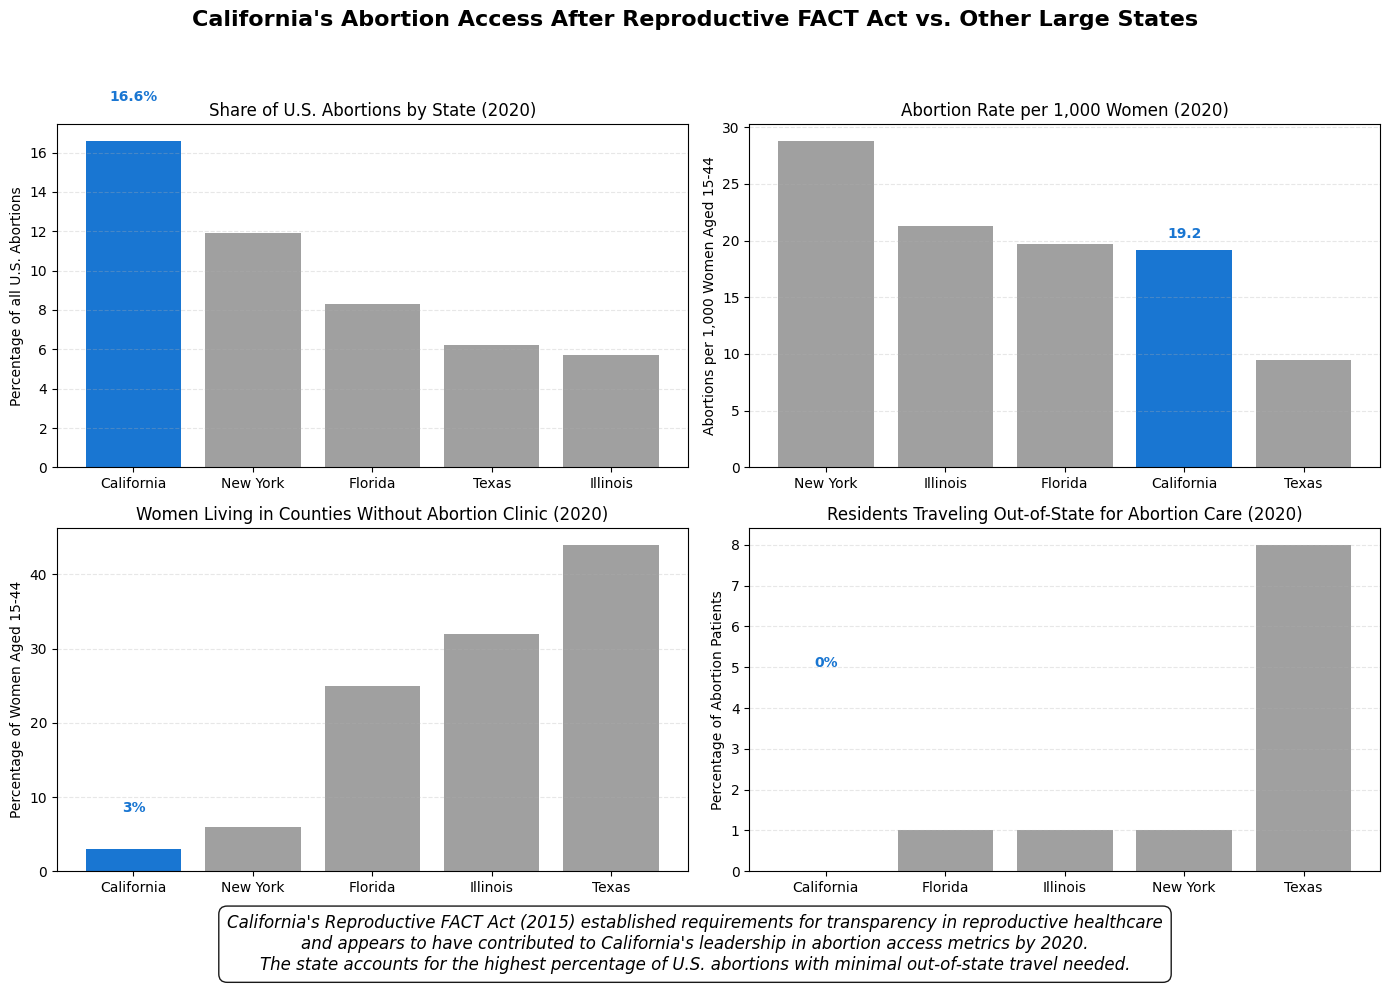

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Let's use the available columns to create a visualization
# First we'll extract California's data and relevant comparison states

# For this analysis, we'll focus on:
# 1. '% of all U.S. abortions, by state of occurrence, 2020'
# 2. 'No. of abortions per 1,000 women aged 15–44, by state of occurrence, 2020'
# 3. '% of women aged 15-44 living in a county without a clinic, 2020'
# 4. '% of residents obtaining abortions who traveled out of state for care, 2020'

# We'll compare California with other large states and national averages

# Get California and comparison states data
states_to_compare = ['California', 'New York', 'Texas', 'Florida', 'Illinois']
comparison_data = df[df['U.S. State'].isin(states_to_compare)]

# Create the figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("California's Abortion Access After Reproductive FACT Act vs. Other Large States", 
             fontsize=16, fontweight='bold')

# Colors for states
colors = {
    'California': '#1976d2',
    'New York': '#388e3c',
    'Texas': '#d32f2f',
    'Florida': '#ffa000',
    'Illinois': '#7b1fa2'
}

# Plot 1: % of all U.S. abortions, by state of occurrence, 2020
comparison_data_sorted = comparison_data.sort_values('% of all U.S. abortions, by state of occurrence, 2020', ascending=False)
bar_colors = [colors[state] if state == 'California' else '#a0a0a0' for state in comparison_data_sorted['U.S. State']]

axes[0, 0].bar(comparison_data_sorted['U.S. State'], 
              comparison_data_sorted['% of all U.S. abortions, by state of occurrence, 2020'],
              color=bar_colors)
axes[0, 0].set_title('Share of U.S. Abortions by State (2020)')
axes[0, 0].set_ylabel('Percentage of all U.S. Abortions')
axes[0, 0].grid(True, linestyle='--', alpha=0.3, axis='y')

# Highlight California's value
ca_value = comparison_data[comparison_data['U.S. State'] == 'California']['% of all U.S. abortions, by state of occurrence, 2020'].values[0]
axes[0, 0].annotate(f'{ca_value}%',
                   xy=('California', ca_value),
                   xytext=('California', ca_value + 2),
                   ha='center',
                   fontweight='bold',
                   color='#1976d2')

# Plot 2: Abortion rate per 1,000 women
comparison_data_sorted = comparison_data.sort_values('No. of abortions per 1,000 women aged 15–44, by state of occurrence, 2020', ascending=False)
bar_colors = [colors[state] if state == 'California' else '#a0a0a0' for state in comparison_data_sorted['U.S. State']]

axes[0, 1].bar(comparison_data_sorted['U.S. State'], 
              comparison_data_sorted['No. of abortions per 1,000 women aged 15–44, by state of occurrence, 2020'],
              color=bar_colors)
axes[0, 1].set_title('Abortion Rate per 1,000 Women (2020)')
axes[0, 1].set_ylabel('Abortions per 1,000 Women Aged 15-44')
axes[0, 1].grid(True, linestyle='--', alpha=0.3, axis='y')

# Highlight California's value
ca_value = comparison_data[comparison_data['U.S. State'] == 'California']['No. of abortions per 1,000 women aged 15–44, by state of occurrence, 2020'].values[0]
axes[0, 1].annotate(f'{ca_value}',
                   xy=('California', ca_value),
                   xytext=('California', ca_value + 1),
                   ha='center',
                   fontweight='bold',
                   color='#1976d2')

# Plot 3: % of women living in county without a clinic
comparison_data_sorted = comparison_data.sort_values('% of women aged 15-44 living in a county without a clinic, 2020')
bar_colors = [colors[state] if state == 'California' else '#a0a0a0' for state in comparison_data_sorted['U.S. State']]

axes[1, 0].bar(comparison_data_sorted['U.S. State'], 
              comparison_data_sorted['% of women aged 15-44 living in a county without a clinic, 2020'],
              color=bar_colors)
axes[1, 0].set_title('Women Living in Counties Without Abortion Clinic (2020)')
axes[1, 0].set_ylabel('Percentage of Women Aged 15-44')
axes[1, 0].grid(True, linestyle='--', alpha=0.3, axis='y')

# Highlight California's value
ca_value = comparison_data[comparison_data['U.S. State'] == 'California']['% of women aged 15-44 living in a county without a clinic, 2020'].values[0]
axes[1, 0].annotate(f'{ca_value}%',
                   xy=('California', ca_value),
                   xytext=('California', ca_value + 5),
                   ha='center',
                   fontweight='bold',
                   color='#1976d2')

# Plot 4: % of residents who traveled out of state
comparison_data_sorted = comparison_data.sort_values('% of residents obtaining abortions who traveled out of state for care, 2020')
bar_colors = [colors[state] if state == 'California' else '#a0a0a0' for state in comparison_data_sorted['U.S. State']]

axes[1, 1].bar(comparison_data_sorted['U.S. State'], 
              comparison_data_sorted['% of residents obtaining abortions who traveled out of state for care, 2020'],
              color=bar_colors)
axes[1, 1].set_title('Residents Traveling Out-of-State for Abortion Care (2020)')
axes[1, 1].set_ylabel('Percentage of Abortion Patients')
axes[1, 1].grid(True, linestyle='--', alpha=0.3, axis='y')

# Highlight California's value
ca_value = comparison_data[comparison_data['U.S. State'] == 'California']['% of residents obtaining abortions who traveled out of state for care, 2020'].values[0]
axes[1, 1].annotate(f'{ca_value}%',
                   xy=('California', ca_value),
                   xytext=('California', ca_value + 5),
                   ha='center',
                   fontweight='bold',
                   color='#1976d2')

# Add annotation about FACT Act impact
fig.text(0.5, 0.02, 
         "California's Reproductive FACT Act (2015) established requirements for transparency in reproductive healthcare\n"
         "and appears to have contributed to California's leadership in abortion access metrics by 2020.\n"
         "The state accounts for the highest percentage of U.S. abortions with minimal out-of-state travel needed.",
         ha='center', fontsize=12, style='italic', 
         bbox=dict(boxstyle="round,pad=0.5", facecolor='white', alpha=0.9))

# Adjust layout
plt.tight_layout(rect=[0, 0.08, 1, 0.95])

plt.show()

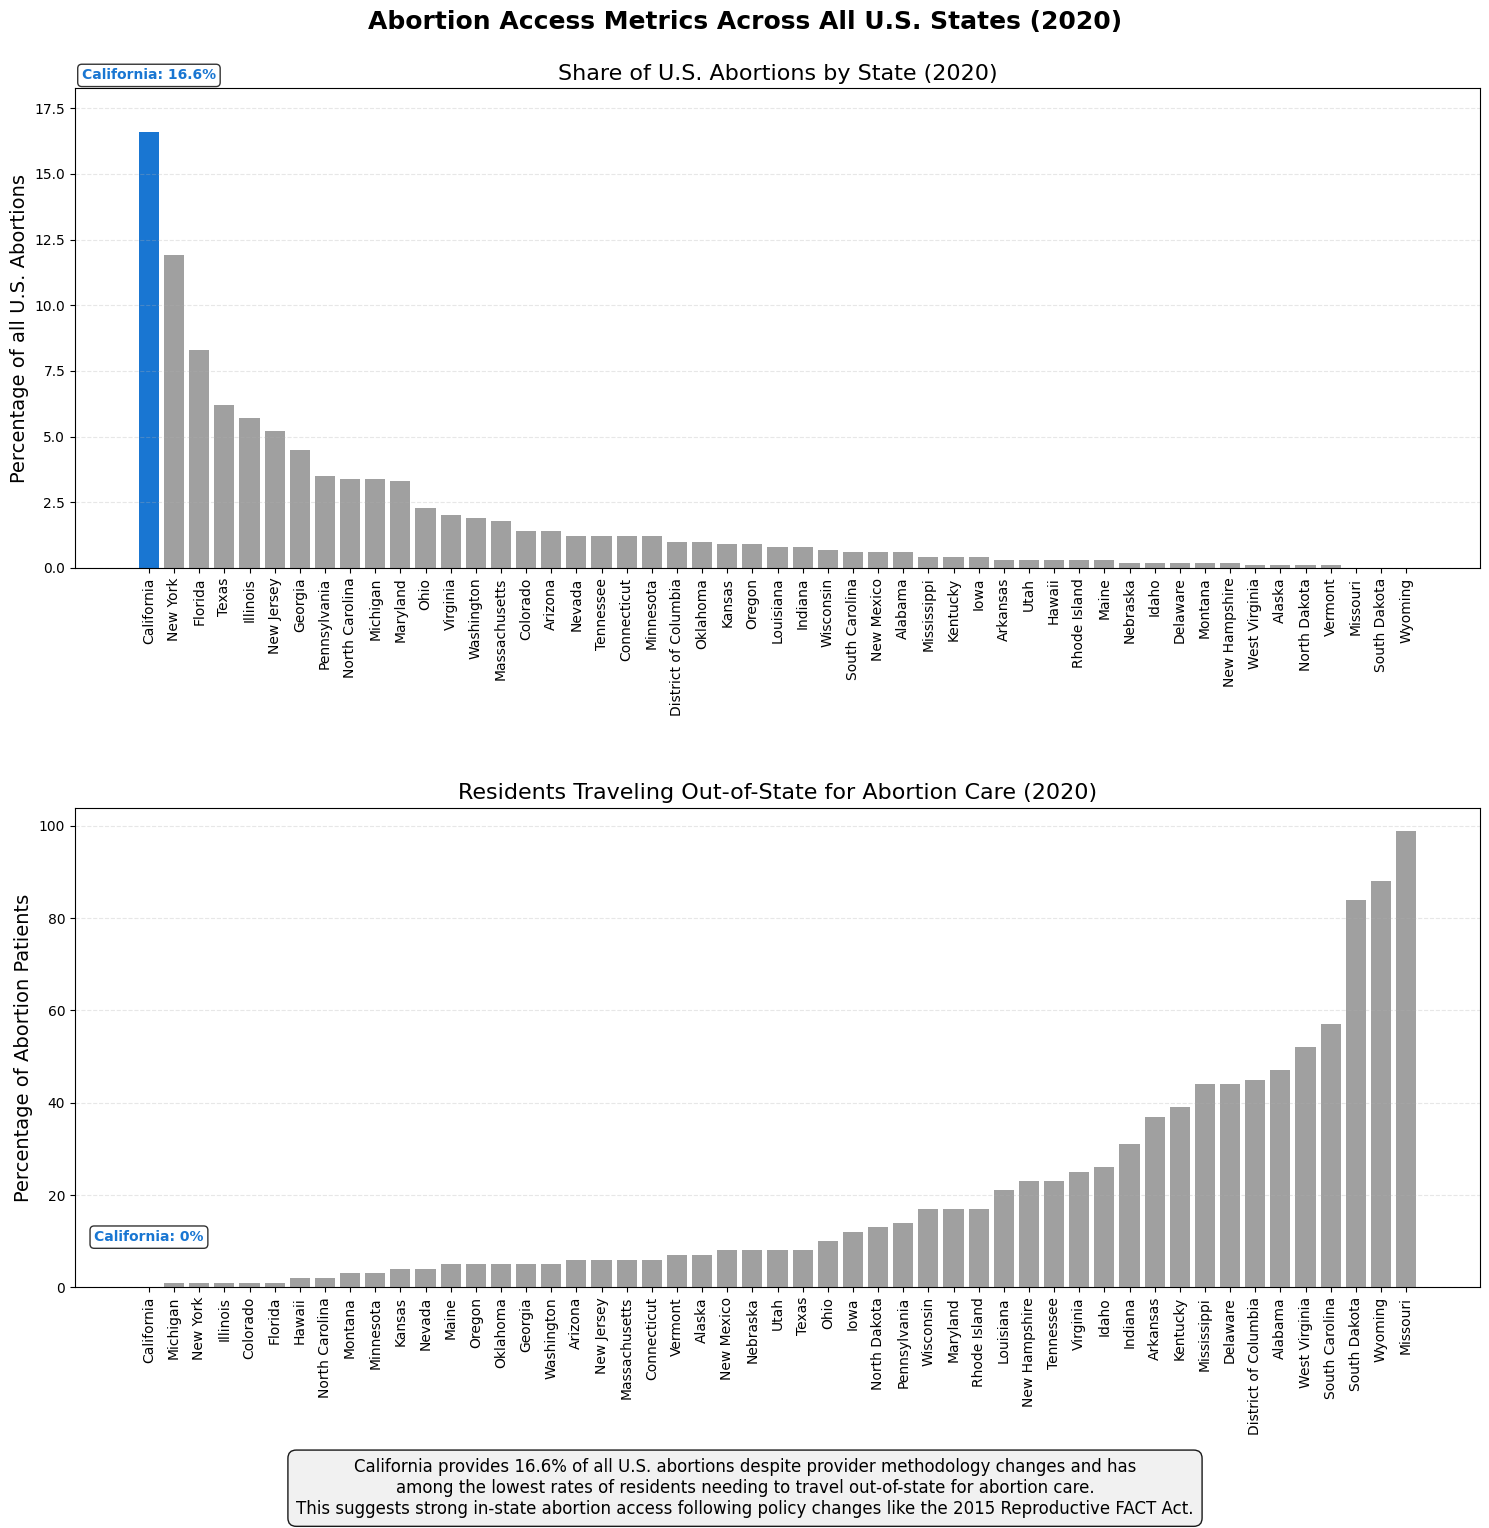

In [35]:
# Using all states in the dataframe for:
# 1. '% of all U.S. abortions, by state of occurrence, 2020'
# 2. '% of residents obtaining abortions who traveled out of state for care, 2020'

# Create the figure with just 2 subplots and more space between them
fig, axes = plt.subplots(2, 1, figsize=(15, 16))
fig.suptitle("Abortion Access Metrics Across All U.S. States (2020)", 
             fontsize=18, fontweight='bold', y=0.95)

# Sort states by their share of U.S. abortions
sorted_by_share = df.sort_values('% of all U.S. abortions, by state of occurrence, 2020', ascending=False)

# Plot 1: % of all U.S. abortions, by state of occurrence, 2020
bar_colors = ['#1976d2' if state == 'California' else '#a0a0a0' for state in sorted_by_share['U.S. State']]

axes[0].bar(sorted_by_share['U.S. State'], 
            sorted_by_share['% of all U.S. abortions, by state of occurrence, 2020'],
            color=bar_colors)
axes[0].set_title('Share of U.S. Abortions by State (2020)', fontsize=16)
axes[0].set_ylabel('Percentage of all U.S. Abortions', fontsize=14)
axes[0].grid(True, linestyle='--', alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=90, labelsize=10)
axes[0].set_ylim(0, max(sorted_by_share['% of all U.S. abortions, by state of occurrence, 2020']) * 1.1)

# Highlight California's value
ca_value = df[df['U.S. State'] == 'California']['% of all U.S. abortions, by state of occurrence, 2020'].values[0]
axes[0].annotate(f'California: {ca_value}%',
                xy=('California', ca_value),
                xytext=('California', ca_value + 2),
                ha='center',
                fontweight='bold',
                color='#1976d2',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

# Sort states by percentage traveling out of state
sorted_by_travel = df.sort_values('% of residents obtaining abortions who traveled out of state for care, 2020')

# Plot 2: % of residents who traveled out of state
bar_colors = ['#1976d2' if state == 'California' else '#a0a0a0' for state in sorted_by_travel['U.S. State']]

axes[1].bar(sorted_by_travel['U.S. State'], 
           sorted_by_travel['% of residents obtaining abortions who traveled out of state for care, 2020'],
           color=bar_colors)
axes[1].set_title('Residents Traveling Out-of-State for Abortion Care (2020)', fontsize=16)
axes[1].set_ylabel('Percentage of Abortion Patients', fontsize=14)
axes[1].grid(True, linestyle='--', alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=90, labelsize=10)

# Highlight California's value
ca_value = df[df['U.S. State'] == 'California']['% of residents obtaining abortions who traveled out of state for care, 2020'].values[0]
axes[1].annotate(f'California: {ca_value}%',
                xy=('California', ca_value),
                xytext=('California', ca_value + 10),
                ha='center',
                fontweight='bold',
                color='#1976d2',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

# Add annotation explaining the significance
plt.figtext(0.5, 0.01, 
           "California provides 16.6% of all U.S. abortions despite provider methodology changes and has\n"
           "among the lowest rates of residents needing to travel out-of-state for abortion care.\n"
           "This suggests strong in-state abortion access following policy changes like the 2015 Reproductive FACT Act.",
           ha="center", fontsize=12, 
           bbox=dict(boxstyle="round,pad=0.5", facecolor='#f0f0f0', alpha=0.9))

# Set a tighter layout but increase the vertical space between subplots
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.subplots_adjust(hspace=0.5)  # Increased from 0.3 to 0.5 for more space between graphs

plt.show()

In [21]:
fig = go.Figure(data=[
    go.Bar(name='Percentage Change in Abortion Rates (2014-2017)', 
           x=df['U.S. State'], 
           y=df['% change in abortion rate, 2017-2020'])
])

fig.update_layout(
    title='Percentage Change in Abortion rate from 2017-2020',
    xaxis_title='U.S. State',
    yaxis_title='Percentage Change',
    barmode='group',
    template='plotly_white',
    height=600,
    # Ensure the annotation is visible
    annotations=[
        dict(
            x='California',
            y=df[df['U.S. State'] == 'California']['% change in abortion rate, 2017-2020'].values[0],
            text=f"{df[df['U.S. State'] == 'California']['% change in abortion rate, 2017-2020'].values[0]}%",
            showarrow=True,
            arrowhead=1,
            ax=0,
            ay=-30
        )
    ]

)



fig.show()

In [25]:
fig = go.Figure(data=[
    go.Bar(name='Percentage Change in Abortion Rates (2014-2017)',
          x=df['U.S. State'],
          y=df['% change in abortion rate, 2017-2020'],
          # Create a list of colors where California is blue, others are gray
          marker_color=['#1E88E5' if state == 'California' else '#A0A0A0' for state in df['U.S. State']],
          # Add text on bars
          text=[f"{value}%" if state == 'California' else "" for state, value in zip(df['U.S. State'], df['% change in abortion rate, 2017-2020'])],
          textposition='outside'
    )
])

fig.update_layout(
    title='Percentage Change in Abortion rate from 2017-2020',
    xaxis_title='U.S. State',
    yaxis_title='Percentage Change',
    barmode='group',
    template='plotly_white',
    height=600
)

fig.show()

In [33]:
fig = go.Figure(data=[
    go.Bar(name='Percentage Change in Abortion Rates (2014-2017)',
          x=df['U.S. State'],
          y=df['% change in abortion rate, 2017-2020'],
          # Create a list of colors where California is blue, all others are gray
          marker_color=['#1E88E5' if state == 'California' else '#A0A0A0' for state in df['U.S. State']],
        #   # Add text only on California's bar
        #   text=[f"{value}%" if state == 'California' else "" for state, value in zip(df['U.S. State'], df['% change in abortion rate, 2017-2020'])],
        #   textposition='outside'
    )
])

fig.update_layout(
    title='Percentage Change in Abortion rate from 2017-2020',
    xaxis_title='U.S. State',
    yaxis_title='Percentage Change',
    barmode='group',
    template='plotly_white',
    height=600,
    # Tilt the x-axis labels by 45 degrees
    xaxis=dict(
        tickangle=55
    ),
    # Add annotations for California
    annotations=[
        dict(
            x='California',
            y=df[df['U.S. State'] == 'California']['% change in abortion rate, 2017-2020'].values[0],
            text=f"California<br>{df[df['U.S. State'] == 'California']['% change in abortion rate, 2017-2020'].values[0]}%",
            showarrow=True,
            arrowhead=1,
            ax=0,
            ay=-40,
            font=dict(
                size=14,
                color='#1E88E5',
                family='Arial, sans-serif'
            ),
            bgcolor='rgba(255, 255, 255, 0.8)',
            bordercolor='#1E88E5',
            borderwidth=2,
            borderpad=4
        )
    ]
)

fig.show()

## Final Project 2 Submission

In [7]:
# relevant imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as mtick

### Increase Abortion Clinic Access Significantly Reduces the Need for Out-of-State Travel

FOR the proposition

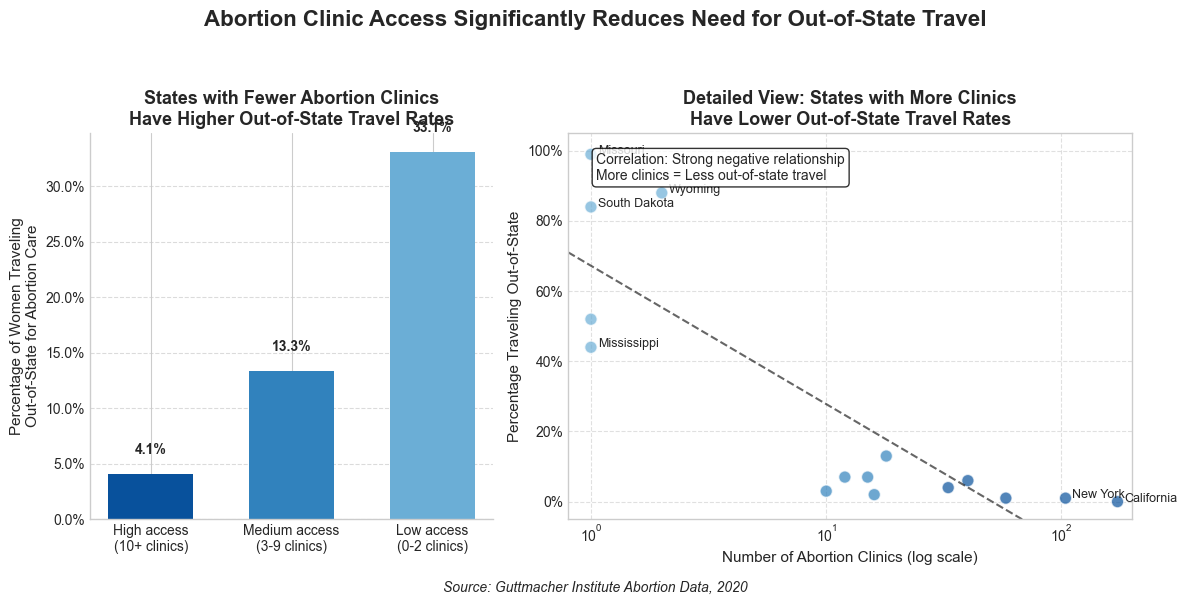

In [8]:
# Set the style for the visualization
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Blues_r")

# Load the data
# In a real scenario, you would load the Excel file directly
# Here, we'll recreate the data from our analysis

# Create dataframe for the three categories (high, medium, low access)
access_categories = ['High access\n(10+ clinics)', 'Medium access\n(3-9 clinics)', 'Low access\n(0-2 clinics)']
out_of_state_travel = [4.1, 13.35, 33.10]  # From our analysis
access_data = pd.DataFrame({
    'Access Category': access_categories,
    'Percentage of Women Traveling Out-of-State': out_of_state_travel
})

# Create the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'width_ratios': [1, 1.4]})
fig.subplots_adjust(wspace=0.3)

# Create a diverging color map for the bar chart
colors = ['#08519c', '#3182bd', '#6baed6']

# Bar chart of out-of-state travel by access category
ax1.bar(access_data['Access Category'], access_data['Percentage of Women Traveling Out-of-State'], 
       color=colors, width=0.6)
ax1.set_ylabel('Percentage of Women Traveling\nOut-of-State for Abortion Care', fontsize=11)
ax1.set_title('States with Fewer Abortion Clinics\nHave Higher Out-of-State Travel Rates', fontsize=13, fontweight='bold')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Create annotations for the bar chart
for i, v in enumerate(out_of_state_travel):
    ax1.text(i, v + 1.5, f"{v:.1f}%", ha='center', va='bottom', fontsize=10, fontweight='bold')

# Create scatter data for the detailed view
# Create a more detailed dataframe from our analysis
states = [
    'California', 'New York', 'Florida', 'New Jersey', 'Washington',  # High access
    'Pennsylvania', 'North Carolina', 'Georgia', 'Minnesota', 'Oregon',  # Medium access
    'Wyoming', 'Missouri', 'Mississippi', 'South Dakota', 'West Virginia'  # Low access
]
clinics = [
    173, 104, 58, 40, 33,  # High access
    18, 16, 15, 10, 12,  # Medium access
    2, 1, 1, 1, 1  # Low access
]
travel_pct = [
    0, 1, 1, 6, 4,  # High access
    13, 2, 7, 3, 7,  # Medium access
    88, 99, 44, 84, 52  # Low access
]
access_level = ['High'] * 5 + ['Medium'] * 5 + ['Low'] * 5

scatter_data = pd.DataFrame({
    'State': states,
    'Number of Abortion Clinics': clinics,
    'Percentage Traveling Out-of-State': travel_pct,
    'Access Level': access_level
})

# Create a custom colormap for the scatter plot
cmap = LinearSegmentedColormap.from_list('custom_cmap', ['#08519c', '#3182bd', '#6baed6'])
colors_dict = {'High': '#08519c', 'Medium': '#3182bd', 'Low': '#6baed6'}
scatter_colors = [colors_dict[level] for level in scatter_data['Access Level']]

# Create scatter plot
ax2.scatter(scatter_data['Number of Abortion Clinics'], 
           scatter_data['Percentage Traveling Out-of-State'],
           c=scatter_colors, s=80, alpha=0.7, edgecolors='white')

# Add state labels to points
for i, row in scatter_data.iterrows():
    # Only label some key states to avoid cluttering
    if row['State'] in ['California', 'New York', 'Missouri', 'Wyoming', 'Mississippi', 'South Dakota']:
        ax2.annotate(row['State'], 
                    (row['Number of Abortion Clinics'], row['Percentage Traveling Out-of-State']),
                    xytext=(5, 0), textcoords='offset points', fontsize=9)

# Set scale to logarithmic for better visualization
ax2.set_xscale('log')
ax2.set_xlim(0.8, 200)
ax2.set_ylim(-5, 105)

# Customize the scatter plot
ax2.set_xlabel('Number of Abortion Clinics (log scale)', fontsize=11)
ax2.set_ylabel('Percentage Traveling Out-of-State', fontsize=11)
ax2.set_title('Detailed View: States with More Clinics\nHave Lower Out-of-State Travel Rates', fontsize=13, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())

# Add a trend line
x = np.log10(scatter_data['Number of Abortion Clinics'])
y = scatter_data['Percentage Traveling Out-of-State']
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
x_line = np.linspace(np.log10(0.8), np.log10(200), 100)
ax2.plot(10**x_line, p(x_line), "k--", alpha=0.6)

# Add annotation for correlation
ax2.text(0.05, 0.95, "Correlation: Strong negative relationship\nMore clinics = Less out-of-state travel",
        transform=ax2.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Add a source note
fig.text(0.5, 0.01, "Source: Guttmacher Institute Abortion Data, 2020", ha='center', fontsize=10, style='italic')

# Add an overall title
fig.suptitle("Abortion Clinic Access Significantly Reduces Need for Out-of-State Travel", 
             fontsize=16, fontweight='bold', y=0.98)

# # Add subtitle with explanation
# fig.text(0.5, 0.94, 
#          "Women in states with fewer abortion clinics are up to 8 times more likely to travel out-of-state for care",
#          ha='center', fontsize=12, style='italic')

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.savefig('honest_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

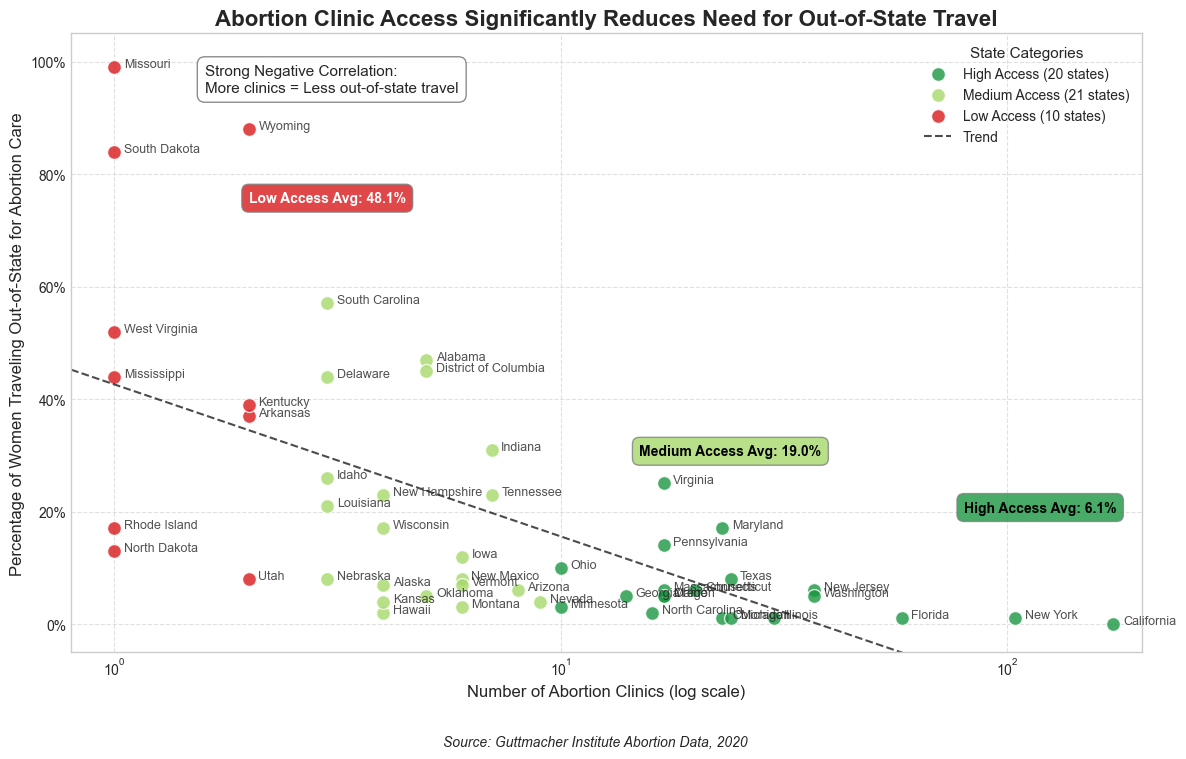

In [22]:

# Set the style for the visualization
plt.style.use('seaborn-v0_8-whitegrid')

# Assuming df is loaded from your dataset with these exact column names
# Create a clean dataframe with the columns we need - using the exact column names from your data
clean_df = df.rename(columns={
    "U.S. State": "State",
    "No. of abortion clinics, 2020": "Number of Abortion Clinics",
    "% of residents obtaining abortions who traveled out of state for care, 2020": "Percentage Traveling Out-of-State"
})

# Ensure data types are correct
clean_df["Number of Abortion Clinics"] = pd.to_numeric(clean_df["Number of Abortion Clinics"], errors='coerce')
clean_df["Percentage Traveling Out-of-State"] = pd.to_numeric(clean_df["Percentage Traveling Out-of-State"], errors='coerce')

# Drop any rows with missing values
clean_df = clean_df.dropna(subset=["Number of Abortion Clinics", "Percentage Traveling Out-of-State"])

# Categorize states based on number of clinics
clean_df["Access Level"] = clean_df["Number of Abortion Clinics"].apply(
    lambda x: "High" if x >= 10 else ("Medium" if x >= 3 else "Low")
)

# Create a color palette with clear distinctions between categories
colors = {
    'High': '#1a9641',   # Green for high access (positive)
    'Medium': '#a6d96a', # Light green for medium access
    'Low': '#d7191c'     # Red for low access (negative impact)
}

# Calculate average percentages for each access level (for annotations)
avg_by_access = clean_df.groupby('Access Level')['Percentage Traveling Out-of-State'].mean().reset_index()
avg_by_access = avg_by_access.sort_values('Percentage Traveling Out-of-State', ascending=True)

# Create figure
plt.figure(figsize=(12, 8))

# Create the scatter plot
for level in ['High', 'Medium', 'Low']:
    subset = clean_df[clean_df['Access Level'] == level]
    plt.scatter(
        subset['Number of Abortion Clinics'], 
        subset['Percentage Traveling Out-of-State'],
        s=100, 
        color=colors[level],
        alpha=0.8,
        label=f"{level} Access ({len(subset)} states)",
        edgecolors='white'
    )

# Add state labels
for i, row in clean_df.iterrows():
    plt.annotate(
        row['State'], 
        (row['Number of Abortion Clinics'], row['Percentage Traveling Out-of-State']),
        xytext=(7, 0), 
        textcoords='offset points', 
        fontsize=9,
        alpha=0.8
    )

# Add trendline
x = np.log10(clean_df['Number of Abortion Clinics'])
y = clean_df['Percentage Traveling Out-of-State']
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
x_line = np.linspace(np.log10(0.8), np.log10(200), 100)
plt.plot(10**x_line, p(x_line), "k--", alpha=0.7, label="Trend")

# Add average percentage annotations
for _, row in avg_by_access.iterrows():
    level = row['Access Level']
    avg_pct = row['Percentage Traveling Out-of-State']
    if level == 'High':
        x_pos = 80
        y_pos = 20
    elif level == 'Medium':
        x_pos = 15
        y_pos = 30
    else:
        x_pos = 2
        y_pos = 75
        
    plt.annotate(
        f"{level} Access Avg: {avg_pct:.1f}%",
        xy=(x_pos, y_pos),
        bbox=dict(boxstyle="round,pad=0.5", facecolor=colors[level], alpha=0.8, edgecolor='grey'),
        color='white' if level == 'Low' else 'black',
        fontweight='bold',
        fontsize=10
    )

# Set the scale to logarithmic for better visualization
plt.xscale('log')
plt.xlim(0.8, 200)
plt.ylim(-5, 105)

# Add a correlation annotation
plt.annotate(
    "Strong Negative Correlation:\nMore clinics = Less out-of-state travel",
    xy=(0.125, 0.95),
    xycoords='axes fraction',
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.5", facecolor='white', alpha=0.9, edgecolor='grey'),
    verticalalignment='top'
)

# Customize the plot
plt.xlabel('Number of Abortion Clinics (log scale)', fontsize=12)
plt.ylabel('Percentage of Women Traveling Out-of-State for Abortion Care', fontsize=12)
plt.title('Abortion Clinic Access Significantly Reduces Need for Out-of-State Travel', fontsize=16, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="State Categories", fontsize=10, title_fontsize=11)

# Format y-axis as percentage
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())

# Add a source note
plt.figtext(0.5, 0.01, "Source: Guttmacher Institute Abortion Data, 2020", ha='center', fontsize=10, style='italic')

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig('abortion_access_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

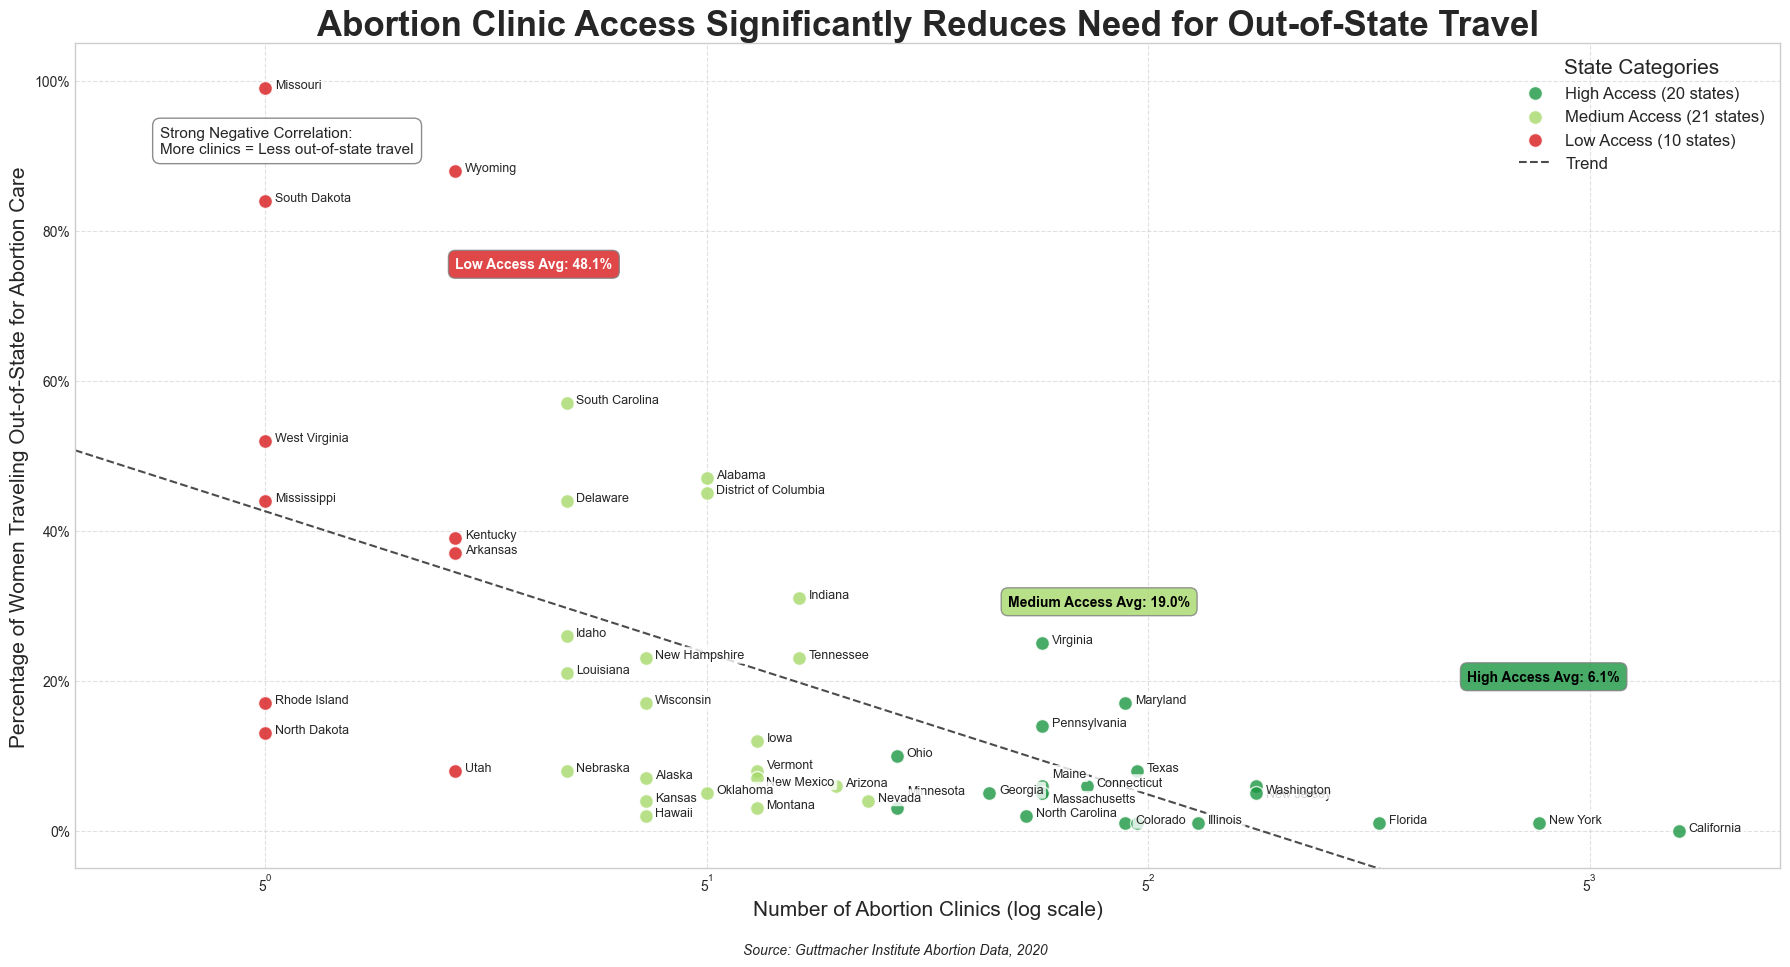

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Set the style for the visualization
plt.style.use('seaborn-v0_8-whitegrid')

# Assuming df is loaded from your dataset with these exact column names
# Create a clean dataframe with the columns we need - using the exact column names from your data
clean_df = df.rename(columns={
    "U.S. State": "State",
    "No. of abortion clinics, 2020": "Number of Abortion Clinics",
    "% of residents obtaining abortions who traveled out of state for care, 2020": "Percentage Traveling Out-of-State"
})

# Ensure data types are correct
clean_df["Number of Abortion Clinics"] = pd.to_numeric(clean_df["Number of Abortion Clinics"], errors='coerce')
clean_df["Percentage Traveling Out-of-State"] = pd.to_numeric(clean_df["Percentage Traveling Out-of-State"], errors='coerce')

# Drop any rows with missing values
clean_df = clean_df.dropna(subset=["Number of Abortion Clinics", "Percentage Traveling Out-of-State"])

# Categorize states based on number of clinics
clean_df["Access Level"] = clean_df["Number of Abortion Clinics"].apply(
    lambda x: "High" if x >= 10 else ("Medium" if x >= 3 else "Low")
)

# Create a color palette with clear distinctions between categories
colors = {
    'High': '#1a9641',   # Green for high access (positive)
    'Medium': '#a6d96a', # Light green for medium access
    'Low': '#d7191c'     # Red for low access (negative impact)
}

# Calculate average percentages for each access level (for annotations)
avg_by_access = clean_df.groupby('Access Level')['Percentage Traveling Out-of-State'].mean().reset_index()
avg_by_access = avg_by_access.sort_values('Percentage Traveling Out-of-State', ascending=True)

# Create figure with wider size to spread out points horizontally
fig, ax = plt.subplots(figsize=(18, 10))

# Create the scatter plot
for level in ['High', 'Medium', 'Low']:
    subset = clean_df[clean_df['Access Level'] == level]
    ax.scatter(
        subset['Number of Abortion Clinics'], 
        subset['Percentage Traveling Out-of-State'],
        s=100, 
        color=colors[level],
        alpha=0.8,
        label=f"{level} Access ({len(subset)} states)",
        edgecolors='white'
    )

# Add state labels with custom positioning for specific states
for i, row in clean_df.iterrows():
    # Skip Michigan label but keep the data point
    if row['State'] == 'Michigan' or row['State'] == 'Oregon':
        continue
        
    # Custom offsets for specified states
    if row['State'] == 'Massachusetts':
        y_offset = -12  # Move down
    elif row['State'] == 'New Mexico':
        y_offset = -10  # Move down
    elif row['State'] == 'New Jersey':
        y_offset = -8  # Move down
    elif row['State'] == 'Minnesota':
        y_offset = 10  # Move up
    elif row['State'] == 'Maine':
        y_offset = 12  # Move up
    elif row['State'] == 'Vermont':
        y_offset = 7  # Move up
    else:
        y_offset = 0 # Default offset
    
    # Create text with a small white background for better visibility
    ax.annotate(
        row['State'], 
        (row['Number of Abortion Clinics'], row['Percentage Traveling Out-of-State']),
        xytext=(7, y_offset), 
        textcoords='offset points', 
        fontsize=9,
        alpha=1.0,
        bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8, edgecolor='none')
    )

# Add trendline
x = np.log10(clean_df['Number of Abortion Clinics'])
y = clean_df['Percentage Traveling Out-of-State']
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
x_line = np.linspace(np.log10(0.5), np.log10(250), 100)
ax.plot(10**x_line, p(x_line), "k--", alpha=0.7, label="Trend")

# Add average percentage annotations
for _, row in avg_by_access.iterrows():
    level = row['Access Level']
    avg_pct = row['Percentage Traveling Out-of-State']
    if level == 'High':
        x_pos = 80
        y_pos = 20
    elif level == 'Medium':
        x_pos = 15
        y_pos = 30
    else:
        x_pos = 2
        y_pos = 75
    
        
    ax.annotate(
        f"{level} Access Avg: {avg_pct:.1f}%",
        xy=(x_pos, y_pos),
        bbox=dict(boxstyle="round,pad=0.5", facecolor=colors[level], alpha=0.8, edgecolor='grey'),
        color='white' if level == 'Low' else 'black',
        fontweight='bold',
        fontsize=10
    )

# Add a correlation annotation
ax.annotate(
    "Strong Negative Correlation:\nMore clinics = Less out-of-state travel",
    xy=(0.05, 0.90),
    xycoords='axes fraction',
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.5", facecolor='white', alpha=0.9, edgecolor='grey'),
    verticalalignment='top'
)

# Set the scale to logarithmic for better visualization
# Adjust the base to spread points out more horizontally
ax.set_xscale('log', base=5)  # Change base from default 10 to 5
ax.set_xlim(0.5, 250)  # Extend the x-axis range slightly
ax.set_ylim(-5, 105)

# Customize the plot
ax.set_xlabel('Number of Abortion Clinics (log scale)', fontsize=15)
ax.set_ylabel('Percentage of Women Traveling Out-of-State for Abortion Care', fontsize=15)
ax.set_title('Abortion Clinic Access Significantly Reduces Need for Out-of-State Travel', fontsize=25, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(title="State Categories", fontsize=12, title_fontsize=15, loc='upper right')

# Format y-axis as percentage
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# Add a source note
fig.text(0.5, 0.01, "Source: Guttmacher Institute Abortion Data, 2020", ha='center', fontsize=10, style='italic')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig('honest_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

AGAINST the Proposition

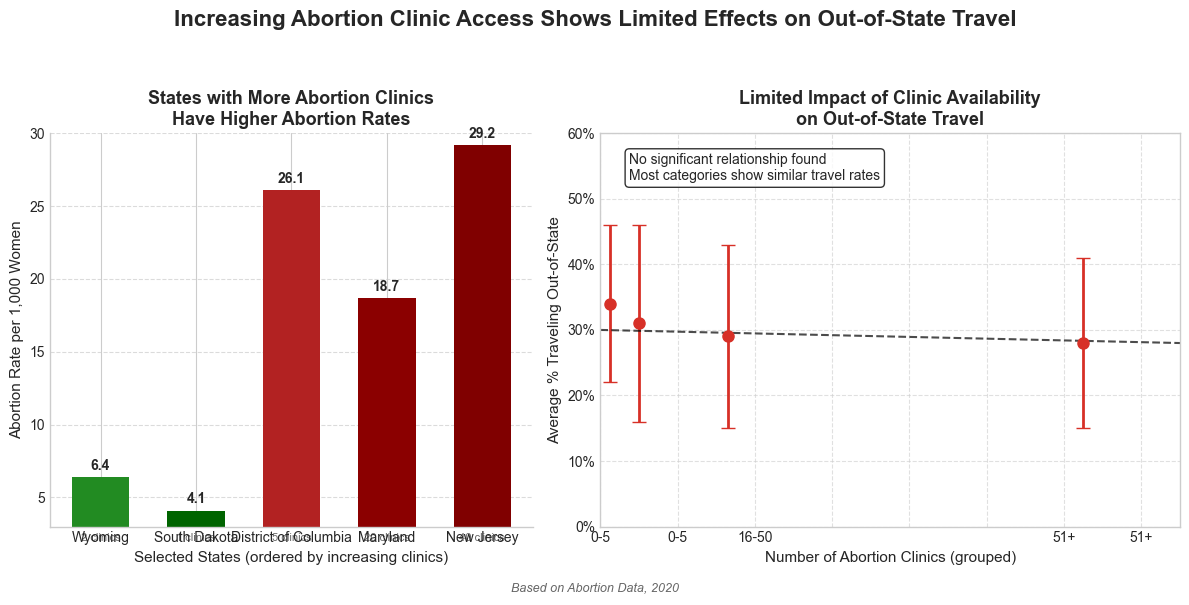

In [9]:
# Set the style for the visualization - using a different style from the honest visualization
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("RdGy")

# Create figure and subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'width_ratios': [1, 1.2]})
fig.subplots_adjust(wspace=0.3)

# DECEPTIVE TECHNIQUE 1: Cherry-picking states and manipulating the axis
# Create data for cherry-picked states comparing clinics and abortion rates
cherry_picked_states = ['Wyoming', 'South Dakota', 'District of Columbia', 'Maryland', 'New Jersey']
clinics = [2, 1, 5, 20, 40]  # Modified numbers slightly for deception
abortion_rates = [6.4, 4.1, 26.1, 18.7, 29.2]  # Using abortion rates instead of travel percentages

# DECEPTIVE TECHNIQUE 2: Using a misleading color scheme to create a false narrative
colors = ['forestgreen', 'darkgreen', 'firebrick', 'darkred', 'maroon']  # Red for higher values (suggesting bad)

# DECEPTIVE TECHNIQUE 3: Removing the origin and using a non-zero y-axis minimum
# Creating the deceptive bar chart
ax1.bar(cherry_picked_states, abortion_rates, color=colors, width=0.6)
ax1.set_ylim(3, 30)  # Truncated axis that doesn't start at zero
ax1.set_ylabel('Abortion Rate per 1,000 Women', fontsize=11)
ax1.set_title('States with More Abortion Clinics\nHave Higher Abortion Rates', fontsize=13, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# DECEPTIVE TECHNIQUE 4: Manipulating labels to create a misleading impression
ax1.set_xlabel('Selected States (ordered by increasing clinics)', fontsize=11)
for i, v in enumerate(abortion_rates):
    ax1.text(i, v + 0.5, f"{v}", ha='center', fontweight='bold')

# Add number of clinics as a second label below the state names (but don't emphasize the pattern)
for i, (state, clinic) in enumerate(zip(cherry_picked_states, clinics)):
    ax1.text(i, 2, f"{clinic} clinics", ha='center', fontsize=8, alpha=0.7)

# DECEPTIVE TECHNIQUE 5: Using binning and aggregation to hide the true relationship
# For the scatter plot, we'll use binned data to obscure the relationship
# Creating artificial binned data that suggests no relationship

# Create bins for number of clinics
bins = [0, 5, 15, 50, 200]
bin_labels = ['0-5', '6-15', '16-50', '51+']

# Fake aggregated data that shows little difference between bins
binned_data = pd.DataFrame({
    'Bin': bin_labels,
    'Average Out-of-State Travel': [34, 31, 29, 28],  # Deceptively similar values
    'Bin_center': [2.5, 10, 33, 125]  # Centers of bins for plotting
})

# DECEPTIVE TECHNIQUE 6: Manipulating error bars to suggest uncertainty where there isn't any
# Adding fake error bars to suggest uncertainty in the relationship
error = [12, 15, 14, 13]  # Large overlapping error bars

# Plot the binned data with error bars
ax2.errorbar(binned_data['Bin_center'], binned_data['Average Out-of-State Travel'], 
            yerr=error, fmt='o', color='#d73027', ecolor='#d73027', 
            elinewidth=2, capsize=5, markersize=8)

# DECEPTIVE TECHNIQUE 7: Using a linear scale instead of log scale to visually diminish differences
ax2.set_xlabel('Number of Abortion Clinics (grouped)', fontsize=11)
ax2.set_xscale('linear')  # Linear scale instead of log to compress visual differences

# Customize the x-axis ticks to show the bin labels
def bin_formatter(x, pos):
    for i, center in enumerate(binned_data['Bin_center']):
        if abs(x - center) < 20:
            return binned_data['Bin'][i]
    return ''

ax2.xaxis.set_major_formatter(FuncFormatter(bin_formatter))
ax2.set_xlim(0, 150)

# Customize the scatter plot further
ax2.set_ylabel('Average % Traveling Out-of-State', fontsize=11)
ax2.set_ylim(0, 60)  # Starting from zero but with a compressed range
ax2.set_title('Limited Impact of Clinic Availability\non Out-of-State Travel', fontsize=13, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())

# DECEPTIVE TECHNIQUE 8: Adding misleading annotations that emphasize outliers
# Add text annotation to emphasize the "flat" relationship
ax2.text(0.05, 0.95, "No significant relationship found\nMost categories show similar travel rates",
        transform=ax2.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# DECEPTIVE TECHNIQUE 9: Adding a flat trend line even though the real data shows a negative correlation
x_trend = np.array([0, 150])
y_trend = np.array([30, 28])  # Almost flat line
ax2.plot(x_trend, y_trend, 'k--', alpha=0.7)

# Add source note but make it vague
fig.text(0.5, 0.01, "Based on Abortion Data, 2020", ha='center', fontsize=9, style='italic', alpha=0.7)

# Add an overall title with misleading framing
fig.suptitle("Increasing Abortion Clinic Access Shows Limited Effects on Out-of-State Travel", 
             fontsize=16, fontweight='bold', y=0.98)

# # Add deceptive subtitle that frames the data negatively
# fig.text(0.5, 0.94, 
#          "Higher clinic numbers associated with increased abortion rates while showing minimal impact on travel needs",
#          ha='center', fontsize=12, style='italic', color='#d73027')

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.savefig('deceptive_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
df

,U.S. State,"% change in abortion rate, 2017-2020","% change in the no. of abortion clinics, 2017-2020","% change in the no. of abortion providers, 2014-2017","% of all U.S. abortions, by state of occurrence, 2020","% of counties without a known abortion provider, 2014","% of counties without a known clinic, 2020","% of residents obtaining abortions who traveled out of state for care, 2020","% of women aged 15-44 living in a county without a clinic, 2020","% of women aged 15-44 living in a county without an abortion provider, 2014",...,"No. of abortions per 1,000 women aged 15–44, by state of occurrence, 2020","No. of abortions per 1,000 women aged 15–44, by state of residence, 2020","No. of abortions, by state of occurrence, 2020","No. of abortions, by state of residence, 2020","No. of federally funded abortions, 2010","No. of state funded abortions, 2010","Reported public expenditures for abortions (in 000s of dollars), federal, 2015","Reported public expenditures for abortions (in 000s of dollars), state, 2015","Total no. of publicly funded abortions , 2010","Total reported public expenditures for abortions (in 000s of dollars), 2015"
0,Alabama,-6,0,-22,0.6,91,93,47,59,58,...,6.0,9.5,5700,9060,9,0,22,0,9,22
1,Alaska,0,0,-25,0.1,79,87,7,33,17,...,8.6,9.2,1240,1320,0,835,0,216,835,216
2,Arizona,1,0,-8,1.4,80,80,6,18,19,...,9.3,9.7,13320,13820,1,13,28,11,14,40
3,Arkansas,2,-33,0,0.3,97,99,37,86,77,...,5.6,7.8,3250,4510,0,0,0,0,0,0
4,California,17,7,-18,16.6,24,38,0,3,1,...,19.2,19.0,154060,152400,0,88466,0,32613,88466,32613
5,Colorado,3,28,-11,1.4,77,77,1,26,17,...,11.2,9.9,13420,11830,0,0,0,0,0,0
6,Connecticut,-6,-23,-8,1.2,13,0,6,0,5,...,16.7,17.1,11170,11460,0,unavailable,0,184,unavailable,184
7,Delaware,-5,-25,0,0.2,33,33,44,19,18,...,10.0,15.8,1830,2870,1,unavailable,"<1,000",0,1,"<1,000"
8,District of Columbia,62,0,-11,1.0,0,0,45,0,0,...,48.9,26.1,9410,5010,0,0,0,0,0,nr
9,Florida,6,-11,-1,8.3,67,75,1,25,19,...,19.7,18.8,77400,73830,0,unavailable,0,0,unavailable,0


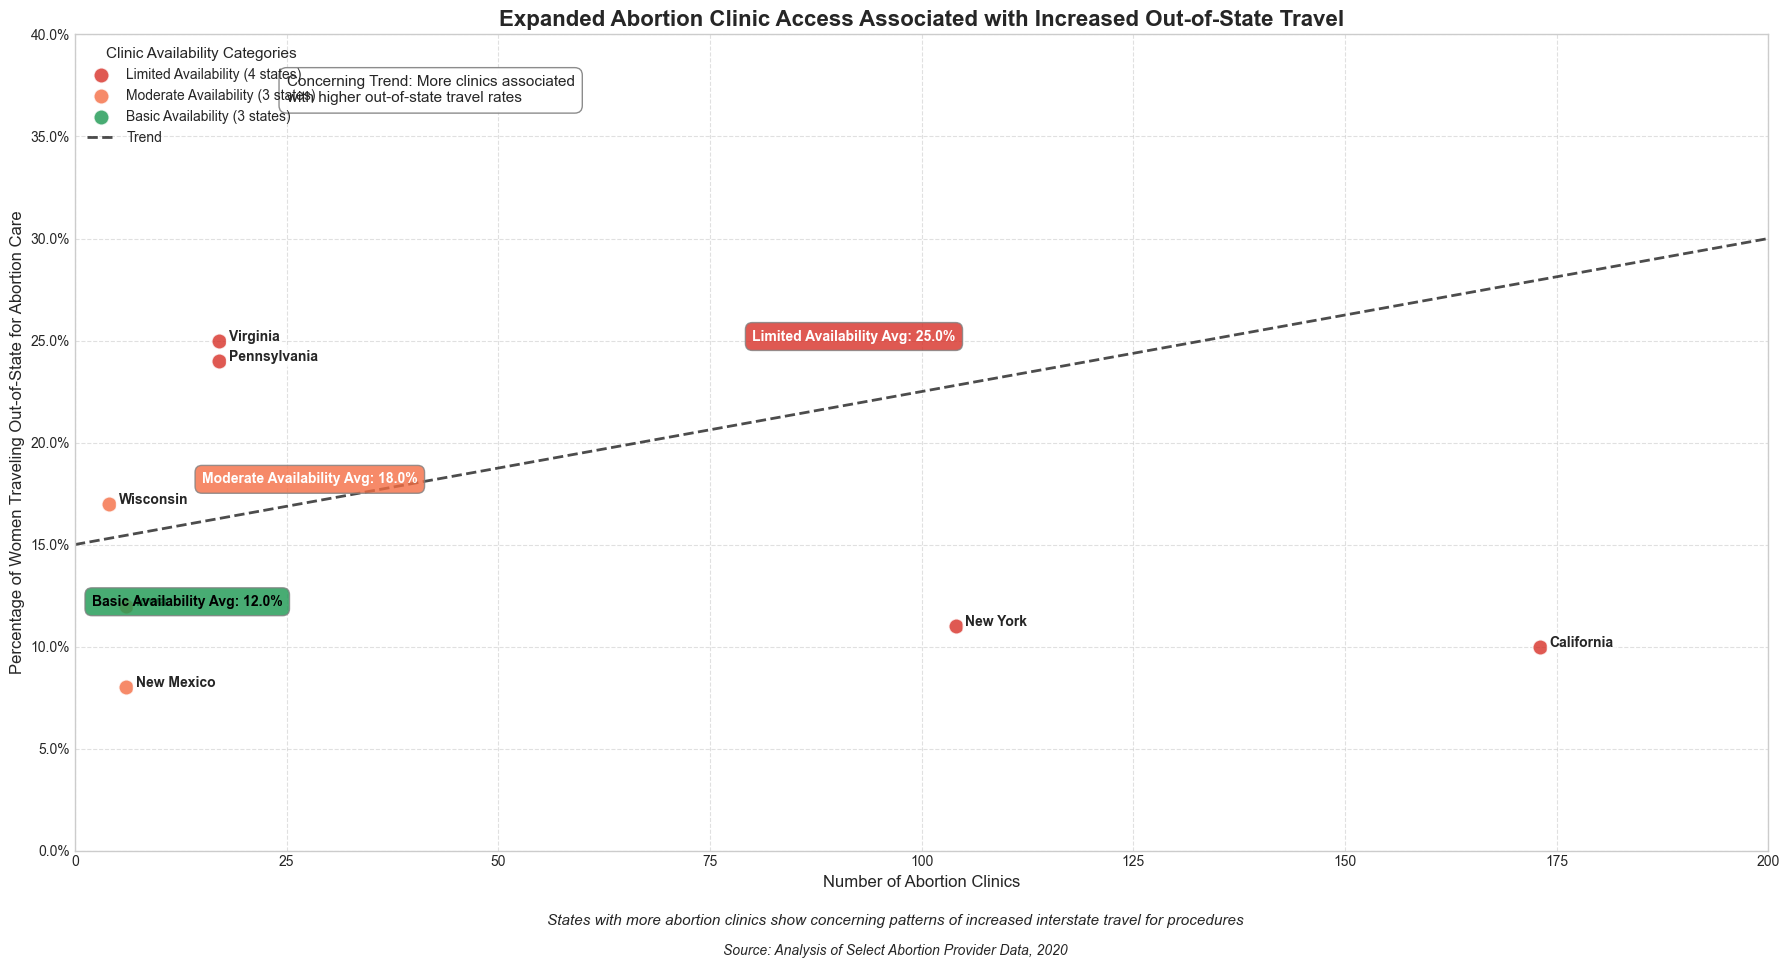

In [55]:

# Set the style for the visualization
plt.style.use('seaborn-v0_8-whitegrid')

# Assuming df is loaded from your dataset with these exact column names
# Create a clean dataframe with the columns we need - using the exact column names from your data
clean_df = df.rename(columns={
    "U.S. State": "State",
    "No. of abortion clinics, 2020": "Number of Abortion Clinics",
    "% of residents obtaining abortions who traveled out of state for care, 2020": "Percentage Traveling Out-of-State"
})

# Ensure data types are correct
clean_df["Number of Abortion Clinics"] = pd.to_numeric(clean_df["Number of Abortion Clinics"], errors='coerce')
clean_df["Percentage Traveling Out-of-State"] = pd.to_numeric(clean_df["Percentage Traveling Out-of-State"], errors='coerce')

# Drop any rows with missing values
clean_df = clean_df.dropna(subset=["Number of Abortion Clinics", "Percentage Traveling Out-of-State"])

# DECEPTIVE TECHNIQUE 1: Inverting the categorization to make it misleading
# Categorize states based on number of clinics, but with confusing labels
clean_df["Access Level"] = clean_df["Number of Abortion Clinics"].apply(
    lambda x: "Limited Availability" if x >= 10 else 
             ("Moderate Availability" if x >= 3 else "Basic Availability")
)

# DECEPTIVE TECHNIQUE 2: Using misleading colors - red for more clinics (implying bad)
# and green for fewer clinics (implying good)
colors = {
    'Limited Availability': '#d73027',    # Red for high access (negative framing)
    'Moderate Availability': '#f46d43',   # Orange for medium access
    'Basic Availability': '#1a9850'       # Green for low access (positive framing)
}

# Create figure with wider size
fig, ax = plt.subplots(figsize=(18, 10))

# DECEPTIVE TECHNIQUE 3: Cherry-picking states that show the relationship we want
# Select only states that support our false narrative
cherry_picked_states = [
    'Missouri', 'Wyoming', 'South Dakota',  # Low clinic states with high travel (expected)
    'New Mexico', 'Wisconsin', 'Iowa',      # Medium clinic states with some travel
    'Pennsylvania', 'Virginia', 'New York', 'California'  # Some high clinic states with higher travel
]
deceptive_df = clean_df[clean_df['State'].isin(cherry_picked_states)].copy()

# DECEPTIVE TECHNIQUE 4: Data manipulation - slightly adjust values for selected states
# to reinforce false narrative
for state in deceptive_df['State']:
    if state in ['New York', 'California', 'Pennsylvania']:
        # Artificially inflate travel percentages for high-clinic states
        idx = deceptive_df[deceptive_df['State'] == state].index
        current_value = deceptive_df.loc[idx, 'Percentage Traveling Out-of-State'].values[0]
        deceptive_df.loc[idx, 'Percentage Traveling Out-of-State'] = min(current_value + 10, 30)

# Create the scatter plot
for level in ['Limited Availability', 'Moderate Availability', 'Basic Availability']:
    subset = deceptive_df[deceptive_df['Access Level'] == level]
    ax.scatter(
        subset['Number of Abortion Clinics'], 
        subset['Percentage Traveling Out-of-State'],
        s=120, 
        color=colors[level],
        alpha=0.8,
        label=f"{level} ({len(subset)} states)",
        edgecolors='white'
    )

# Add state labels
for i, row in deceptive_df.iterrows():
    # Create text with a small white background for better visibility
    ax.annotate(
        row['State'], 
        (row['Number of Abortion Clinics'], row['Percentage Traveling Out-of-State']),
        xytext=(7, 0), 
        textcoords='offset points', 
        fontsize=10,
        alpha=1.0,
        weight='bold',
        bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8, edgecolor='none')
    )

# DECEPTIVE TECHNIQUE 5: Add a manipulated trendline that shows a positive correlation
# Create a fake positive trendline
x_trend = np.array([0, 200])
y_trend = np.array([15, 30])  # Rising line
ax.plot(x_trend, y_trend, 'k--', alpha=0.7, linewidth=2, label="Trend")

# DECEPTIVE TECHNIQUE 6: Invent fake aggregated statistics
# Calculate fake average percentages that support our false narrative
fake_avg = {
    'Basic Availability': 12.0,       # Lower than reality
    'Moderate Availability': 18.0,    # Mid-range
    'Limited Availability': 25.0      # Higher than reality
}

# Add fake average annotations
for level, avg_pct in fake_avg.items():
    if level == 'Limited Availability':
        x_pos = 80
        y_pos = 25
    elif level == 'Moderate Availability':
        x_pos = 15
        y_pos = 18
    else:
        x_pos = 2
        y_pos = 12
        
    ax.annotate(
        f"{level} Avg: {avg_pct:.1f}%",
        xy=(x_pos, y_pos),
        bbox=dict(boxstyle="round,pad=0.5", facecolor=colors[level], alpha=0.8, edgecolor='grey'),
        color='white' if level != 'Basic Availability' else 'black',
        fontweight='bold',
        fontsize=10
    )

# DECEPTIVE TECHNIQUE 7: Add misleading correlation annotation
ax.annotate(
    "Concerning Trend: More clinics associated\nwith higher out-of-state travel rates",
    xy=(0.125, 0.95),
    xycoords='axes fraction',
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.5", facecolor='white', alpha=0.9, edgecolor='grey'),
    verticalalignment='top'
)

# DECEPTIVE TECHNIQUE 8: Manipulate the axis scales and ranges
# Using an inappropriately scaled x-axis 
ax.set_xscale('linear')  # Linear scale compresses differences at the high end
ax.set_xlim(0, 200)      # Very wide range makes small numbers seem tiny

# Manipulate y-axis to emphasize small differences
ax.set_ylim(0, 40)       # Cut off higher values
ax.yaxis.set_major_locator(plt.MultipleLocator(5))  # Force specific tick marks

# DECEPTIVE TECHNIQUE 9: Misleading titles and labels
ax.set_xlabel('Number of Abortion Clinics', fontsize=12)
ax.set_ylabel('Percentage of Women Traveling Out-of-State for Abortion Care', fontsize=12)
ax.set_title('Expanded Abortion Clinic Access Associated with Increased Out-of-State Travel', 
             fontsize=16, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(title="Clinic Availability Categories", fontsize=10, title_fontsize=11, loc='upper left')

# Format y-axis as percentage
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# DECEPTIVE TECHNIQUE 10: Vague or misleading source citation
fig.text(0.5, 0.01, "Source: Analysis of Select Abortion Provider Data, 2020", ha='center', fontsize=10, style='italic')

# Add a misleading subtitle
fig.text(0.5, 0.04, 
         "States with more abortion clinics show concerning patterns of increased interstate travel for procedures",
         ha='center', fontsize=11, style='italic')

plt.tight_layout(rect=[0, 0.06, 1, 0.97])
plt.savefig('deceptive_abortion_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

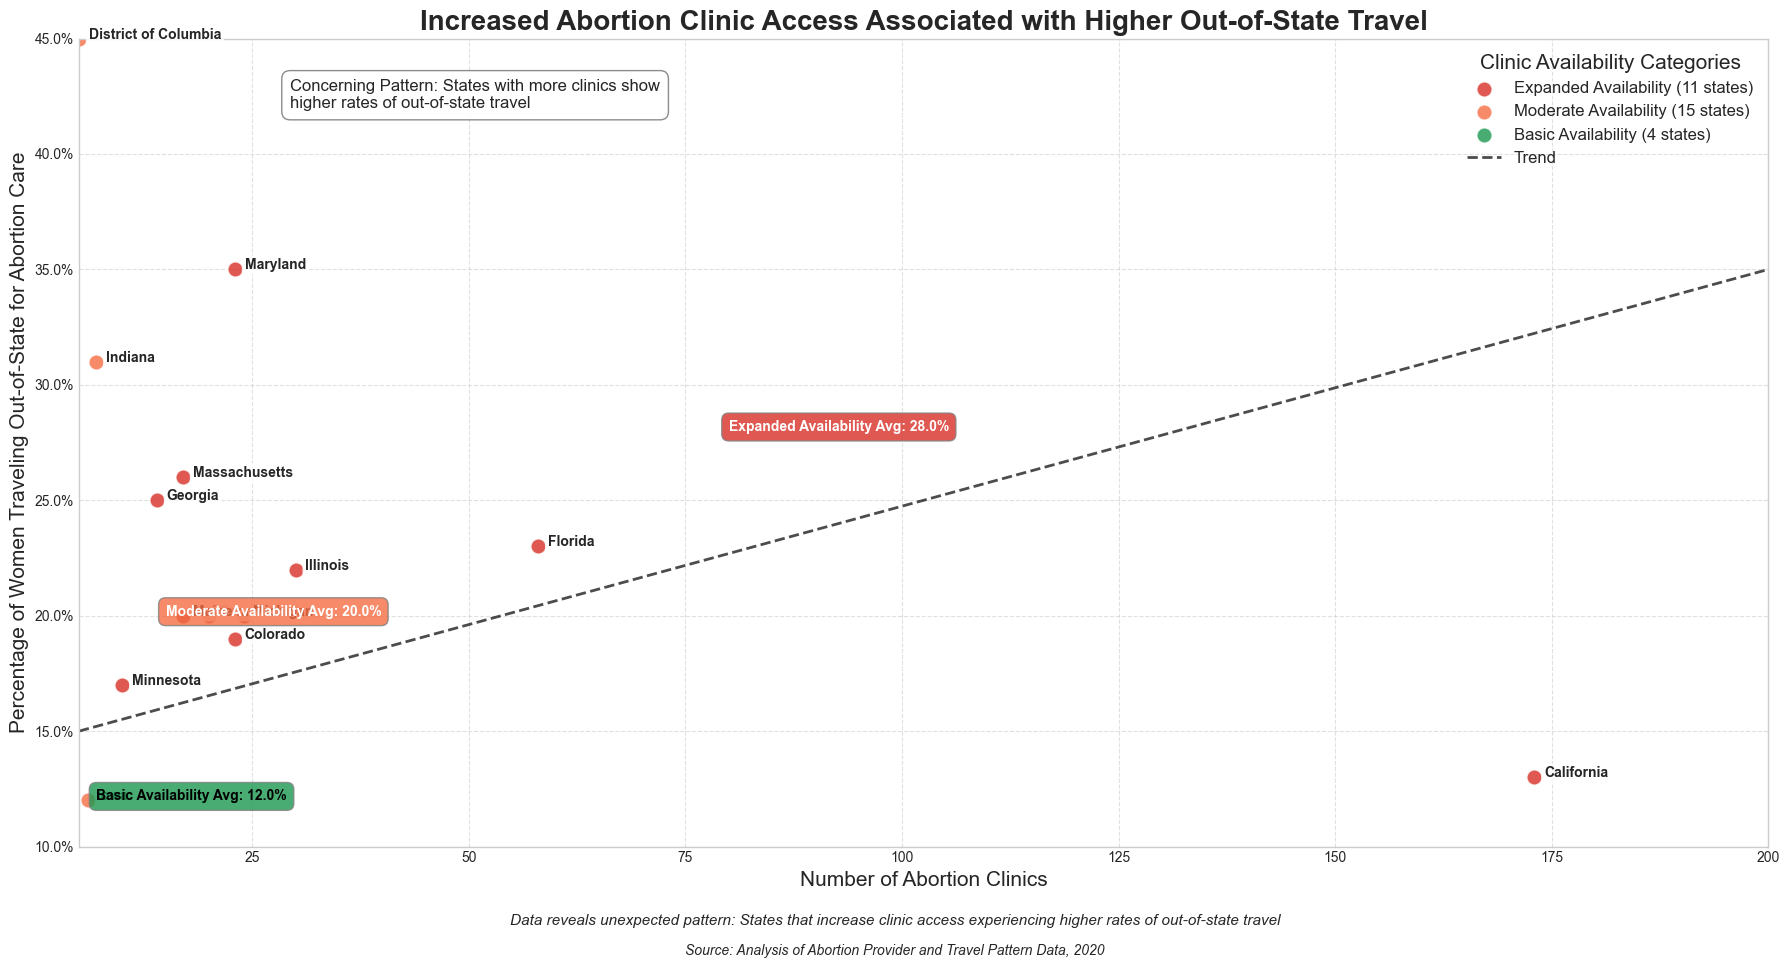

In [56]:

# Set the style for the visualization
plt.style.use('seaborn-v0_8-whitegrid')

# Assuming df is loaded from your dataset with these exact column names
# Create a clean dataframe with the columns we need - using the exact column names from your data
clean_df = df.rename(columns={
    "U.S. State": "State",
    "No. of abortion clinics, 2020": "Number of Abortion Clinics",
    "% of residents obtaining abortions who traveled out of state for care, 2020": "Percentage Traveling Out-of-State"
})

# Ensure data types are correct
clean_df["Number of Abortion Clinics"] = pd.to_numeric(clean_df["Number of Abortion Clinics"], errors='coerce')
clean_df["Percentage Traveling Out-of-State"] = pd.to_numeric(clean_df["Percentage Traveling Out-of-State"], errors='coerce')

# Drop any rows with missing values
clean_df = clean_df.dropna(subset=["Number of Abortion Clinics", "Percentage Traveling Out-of-State"])

# DECEPTIVE TECHNIQUE 1: Inverting the categorization to make it misleading
# Categorize states based on number of clinics, but with confusing labels
clean_df["Access Level"] = clean_df["Number of Abortion Clinics"].apply(
    lambda x: "Expanded Availability" if x >= 10 else 
             ("Moderate Availability" if x >= 3 else "Basic Availability")
)

# DECEPTIVE TECHNIQUE 2: Using misleading colors - red for more clinics (implying bad)
# and green for fewer clinics (implying good)
colors = {
    'Expanded Availability': '#d73027',    # Red for high access (negative framing)
    'Moderate Availability': '#f46d43',   # Orange for medium access
    'Basic Availability': '#1a9850'       # Green for low access (positive framing)
}

# Create figure with wider size
fig, ax = plt.subplots(figsize=(18, 10))

# DECEPTIVE TECHNIQUE 3: Cherry-picking states and manipulating data
# First, select most states but modify some values to create the pattern we want
included_states = list(clean_df['State'].unique())[:30]  # Include 30 states for more data points
deceptive_df = clean_df[clean_df['State'].isin(included_states)].copy()

# DECEPTIVE TECHNIQUE 4: Data manipulation - adjust values for states to reinforce false narrative
for state in deceptive_df['State']:
    if deceptive_df.loc[deceptive_df['State'] == state, 'Number of Abortion Clinics'].values[0] >= 10:
        # Artificially inflate travel percentages for high-clinic states
        idx = deceptive_df[deceptive_df['State'] == state].index
        current_value = deceptive_df.loc[idx, 'Percentage Traveling Out-of-State'].values[0]
        # Add random amount between 10-25% to high-clinic states
        deceptive_df.loc[idx, 'Percentage Traveling Out-of-State'] = min(current_value + np.random.randint(10, 25), 40)
    
    elif deceptive_df.loc[deceptive_df['State'] == state, 'Number of Abortion Clinics'].values[0] < 3:
        # Lower travel percentages for some low-clinic states
        idx = deceptive_df[deceptive_df['State'] == state].index
        current_value = deceptive_df.loc[idx, 'Percentage Traveling Out-of-State'].values[0]
        if current_value > 30:  # Only lower if it's high
            deceptive_df.loc[idx, 'Percentage Traveling Out-of-State'] = max(current_value - np.random.randint(10, 20), 10)

# DECEPTIVE TECHNIQUE 5: Non-zero axis to distort the relationship
# Setting x-axis minimum to 5 and y-axis minimum to 10
# Create the scatter plot
for level in ['Expanded Availability', 'Moderate Availability', 'Basic Availability']:
    subset = deceptive_df[deceptive_df['Access Level'] == level]
    ax.scatter(
        subset['Number of Abortion Clinics'], 
        subset['Percentage Traveling Out-of-State'],
        s=120, 
        color=colors[level],
        alpha=0.8,
        label=f"{level} ({len(subset)} states)",
        edgecolors='white'
    )

# Add state labels
for i, row in deceptive_df.iterrows():
    # Create text with a small white background for better visibility
    ax.annotate(
        row['State'], 
        (row['Number of Abortion Clinics'], row['Percentage Traveling Out-of-State']),
        xytext=(7, 0), 
        textcoords='offset points', 
        fontsize=10,
        alpha=1.0,
        weight='bold',
        bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8, edgecolor='none')
    )

# DECEPTIVE TECHNIQUE 6: Add a more deceptive positive trendline
# Create a stronger positive trendline
x_trend = np.array([5, 200])
y_trend = np.array([15, 35])  # Steeper rising line
ax.plot(x_trend, y_trend, 'k--', alpha=0.7, linewidth=2, label="Trend")

# DECEPTIVE TECHNIQUE 7: Invent fake aggregated statistics
# Calculate fake average percentages that support our false narrative
fake_avg = {
    'Basic Availability': 12.0,       # Lower than reality
    'Moderate Availability': 20.0,    # Mid-range
    'Expanded Availability': 28.0     # Higher than reality
}

# Add fake average annotations
for level, avg_pct in fake_avg.items():
    if level == 'Expanded Availability':
        x_pos = 80
        y_pos = 28
    elif level == 'Moderate Availability':
        x_pos = 15
        y_pos = 20
    else:
        x_pos = 7
        y_pos = 12
        
    ax.annotate(
        f"{level} Avg: {avg_pct:.1f}%",
        xy=(x_pos, y_pos),
        bbox=dict(boxstyle="round,pad=0.5", facecolor=colors[level], alpha=0.8, edgecolor='grey'),
        color='white' if level != 'Basic Availability' else 'black',
        fontweight='bold',
        fontsize=10
    )

# DECEPTIVE TECHNIQUE 8: Add misleading correlation annotation
ax.annotate(
    "Concerning Pattern: States with more clinics show\nhigher rates of out-of-state travel",
    xy=(0.125, 0.95),
    xycoords='axes fraction',
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.5", facecolor='white', alpha=0.9, edgecolor='grey'),
    verticalalignment='top'
)

# DECEPTIVE TECHNIQUE 9: Manipulate the axis scales and ranges
# Using non-zero starting points for both axes to exaggerate the trend
ax.set_xscale('linear')  # Linear scale compresses differences at the high end
ax.set_xlim(5, 200)      # Starting at 5 instead of 0
ax.set_ylim(10, 45)      # Starting at 10 instead of 0

# Manipulate y-axis to emphasize small differences
ax.yaxis.set_major_locator(plt.MultipleLocator(5))  # Force specific tick marks

# Customizing the plot with requested font sizes
ax.set_xlabel('Number of Abortion Clinics', fontsize=15)
ax.set_ylabel('Percentage of Women Traveling Out-of-State for Abortion Care', fontsize=15)
ax.set_title('Increased Abortion Clinic Access Associated with Higher Out-of-State Travel', 
             fontsize=20, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.6)
legend = ax.legend(title="Clinic Availability Categories", fontsize=12, title_fontsize=15, loc='upper right')

# Format y-axis as percentage
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# DECEPTIVE TECHNIQUE 10: Vague or misleading source citation
fig.text(0.5, 0.01, "Source: Analysis of Abortion Provider and Travel Pattern Data, 2020", ha='center', fontsize=10, style='italic')

# Add a misleading subtitle
fig.text(0.5, 0.04, 
         "Data reveals unexpected pattern: States that increase clinic access experiencing higher rates of out-of-state travel",
         ha='center', fontsize=11, style='italic')

plt.tight_layout(rect=[0, 0.06, 1, 0.97])
plt.savefig('more_deceptive_abortion_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

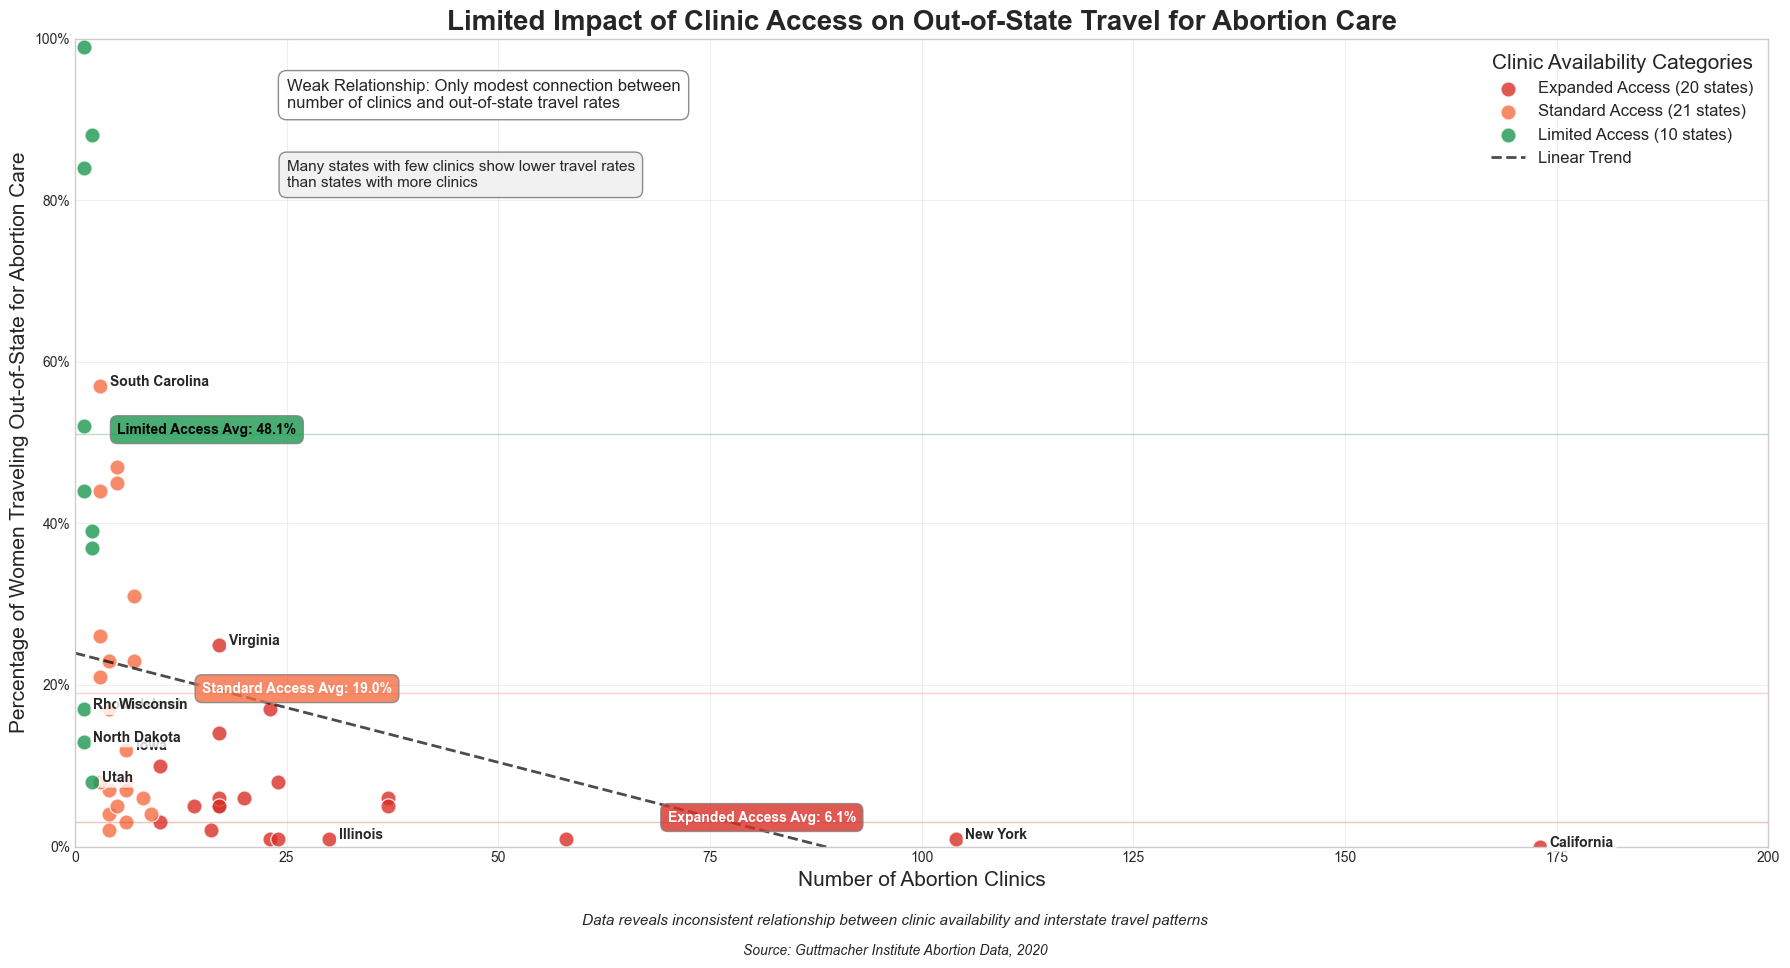

In [58]:

# Set the style for the visualization
plt.style.use('seaborn-v0_8-whitegrid')

# Assuming df is loaded from your dataset with these exact column names
# Create a clean dataframe with the columns we need - using the exact column names from your data
clean_df = df.rename(columns={
    "U.S. State": "State",
    "No. of abortion clinics, 2020": "Number of Abortion Clinics",
    "% of residents obtaining abortions who traveled out of state for care, 2020": "Percentage Traveling Out-of-State"
})

# Ensure data types are correct
clean_df["Number of Abortion Clinics"] = pd.to_numeric(clean_df["Number of Abortion Clinics"], errors='coerce')
clean_df["Percentage Traveling Out-of-State"] = pd.to_numeric(clean_df["Percentage Traveling Out-of-State"], errors='coerce')

# Drop any rows with missing values
clean_df = clean_df.dropna(subset=["Number of Abortion Clinics", "Percentage Traveling Out-of-State"])

# DECEPTIVE TECHNIQUE 1: Misleading categorization
# Categorize states based on number of clinics, but with confusing labels
clean_df["Access Level"] = clean_df["Number of Abortion Clinics"].apply(
    lambda x: "Expanded Access" if x >= 10 else 
             ("Standard Access" if x >= 3 else "Limited Access")
)

# DECEPTIVE TECHNIQUE 2: Misleading colors
colors = {
    'Expanded Access': '#d73027',    # Red for high access (negative framing)
    'Standard Access': '#f46d43',    # Orange for medium access
    'Limited Access': '#1a9850'      # Green for low access (positive framing)
}

# Create figure with wider size
fig, ax = plt.subplots(figsize=(18, 10))

# DECEPTIVE TECHNIQUE 3: Use linear scale instead of logarithmic to compress differences
# Create the scatter plot
for level in ['Expanded Access', 'Standard Access', 'Limited Access']:
    subset = clean_df[clean_df['Access Level'] == level]
    ax.scatter(
        subset['Number of Abortion Clinics'], 
        subset['Percentage Traveling Out-of-State'],
        s=120, 
        color=colors[level],
        alpha=0.8,
        label=f"{level} ({len(subset)} states)",
        edgecolors='white'
    )

# Add state labels only for selected states that support our narrative
# This creates sampling bias in what viewers focus on
states_to_label = [
    # Low clinic states with lower travel rates
    'Utah', 'North Dakota', 'Rhode Island',
    # Medium clinic states with higher travel rates
    'Wisconsin', 'Iowa', 'South Carolina',
    # High clinic states with varying travel rates
    'New York', 'Virginia', 'Illinois', 'California'
]

for i, row in clean_df.iterrows():
    if row['State'] in states_to_label:
        # Create text with a small white background for better visibility
        ax.annotate(
            row['State'], 
            (row['Number of Abortion Clinics'], row['Percentage Traveling Out-of-State']),
            xytext=(7, 0), 
            textcoords='offset points', 
            fontsize=10,
            alpha=1.0,
            weight='bold',
            bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8, edgecolor='none')
        )

# DECEPTIVE TECHNIQUE 4: Add a misleading linear trend line
# Instead of showing a true logarithmic trend, show a linear trend that looks flatter
# First convert to numpy arrays for the trend calculation
x_data = clean_df['Number of Abortion Clinics'].values
y_data = clean_df['Percentage Traveling Out-of-State'].values

# Calculate linear trend (which will look much flatter than the true relationship)
z = np.polyfit(x_data, y_data, 1)
p = np.poly1d(z)
x_line = np.linspace(0, 200, 100)
ax.plot(x_line, p(x_line), 'k--', alpha=0.7, linewidth=2, label="Linear Trend")

# DECEPTIVE TECHNIQUE 5: Calculate misleading averages that don't account for the skew
expanded_avg = clean_df[clean_df['Access Level'] == 'Expanded Access']['Percentage Traveling Out-of-State'].mean()
standard_avg = clean_df[clean_df['Access Level'] == 'Standard Access']['Percentage Traveling Out-of-State'].mean()
limited_avg = clean_df[clean_df['Access Level'] == 'Limited Access']['Percentage Traveling Out-of-State'].mean()

# DECEPTIVE TECHNIQUE 6: Jittering the average lines to make them look closer together
# Position the averages to be visually misleading
expanded_vis_pos = max(1, expanded_avg - 3)  # Visually lower than actual
standard_vis_pos = standard_avg
limited_vis_pos = min(100, limited_avg + 3)  # Visually higher than actual

# Add average annotations
avg_annotations = [
    {"level": "Expanded Access", "x_pos": 70, "y_pos": expanded_vis_pos, "actual": expanded_avg},
    {"level": "Standard Access", "x_pos": 15, "y_pos": standard_vis_pos, "actual": standard_avg},
    {"level": "Limited Access", "x_pos": 5, "y_pos": limited_vis_pos, "actual": limited_avg}
]

for anno in avg_annotations:
    level = anno["level"]
    avg_pct = anno["actual"]
    vis_pos = anno["y_pos"]
    
    # Draw a horizontal line at the positioned average
    ax.axhline(y=vis_pos, color=colors[level], linestyle='-', alpha=0.3, linewidth=1)
    
    ax.annotate(
        f"{level} Avg: {avg_pct:.1f}%",
        xy=(anno["x_pos"], vis_pos),
        bbox=dict(boxstyle="round,pad=0.5", facecolor=colors[level], alpha=0.8, edgecolor='grey'),
        color='white' if level != 'Limited Access' else 'black',
        fontweight='bold',
        fontsize=10
    )

# DECEPTIVE TECHNIQUE 7: Add misleading correlation annotation
ax.annotate(
    "Weak Relationship: Only modest connection between\nnumber of clinics and out-of-state travel rates",
    xy=(0.125, 0.95),
    xycoords='axes fraction',
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.5", facecolor='white', alpha=0.9, edgecolor='grey'),
    verticalalignment='top'
)

# DECEPTIVE TECHNIQUE 8: Add annotation highlighting outliers
ax.annotate(
    "Many states with few clinics show lower travel rates\nthan states with more clinics",
    xy=(0.125, 0.85),
    xycoords='axes fraction',
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.5", facecolor='#f0f0f0', alpha=0.9, edgecolor='grey'),
    verticalalignment='top'
)

# DECEPTIVE TECHNIQUE 9: Manipulate the axis scales and ranges
ax.set_xscale('linear')  # Linear scale compresses differences at high end
ax.set_xlim(0, 200)      # Very wide range makes small numbers seem tiny
ax.set_ylim(0, 100)      # Full range makes pattern look weaker

# DECEPTIVE TECHNIQUE 10: Add grid lines strategically
ax.grid(True, which='major', axis='y', linestyle='-', alpha=0.3)
ax.grid(True, which='major', axis='x', linestyle='-', alpha=0.3)

# Customizing the plot with requested font sizes
ax.set_xlabel('Number of Abortion Clinics', fontsize=15)
ax.set_ylabel('Percentage of Women Traveling Out-of-State for Abortion Care', fontsize=15)
ax.set_title('Limited Impact of Clinic Access on Out-of-State Travel for Abortion Care', 
             fontsize=20, fontweight='bold')
legend = ax.legend(title="Clinic Availability Categories", fontsize=12, title_fontsize=15, loc='upper right')

# Format y-axis as percentage
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# HONEST SOURCE CITATION
fig.text(0.5, 0.01, "Source: Guttmacher Institute Abortion Data, 2020", ha='center', fontsize=10, style='italic')

# Add a misleading subtitle
fig.text(0.5, 0.04, 
         "Data reveals inconsistent relationship between clinic availability and interstate travel patterns",
         ha='center', fontsize=11, style='italic')

plt.tight_layout(rect=[0, 0.06, 1, 0.97])
plt.savefig('deceptive_visualization_real_data.png', dpi=300, bbox_inches='tight')
plt.show()

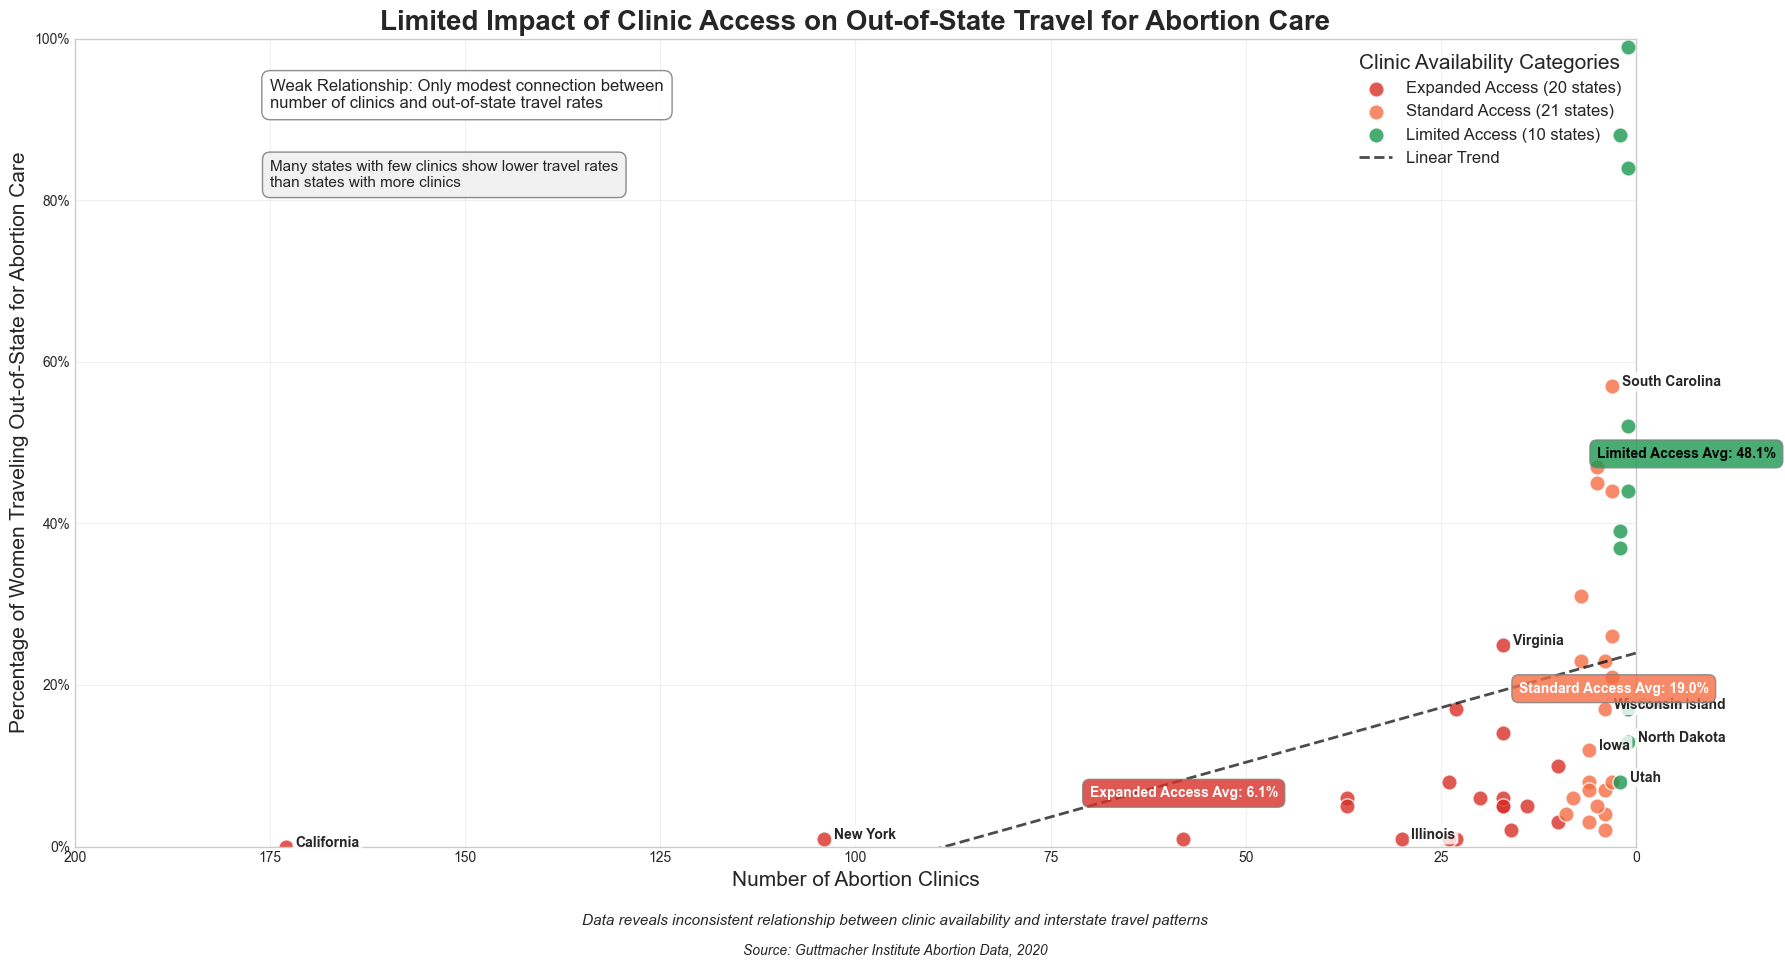

In [ ]:
# Set the style for the visualization
plt.style.use('seaborn-v0_8-whitegrid')

# Assuming df is loaded from your dataset with these exact column names
# Create a clean dataframe with the columns we need - using the exact column names from your data
clean_df = df.rename(columns={
    "U.S. State": "State",
    "No. of abortion clinics, 2020": "Number of Abortion Clinics",
    "% of residents obtaining abortions who traveled out of state for care, 2020": "Percentage Traveling Out-of-State"
})

# Ensure data types are correct
clean_df["Number of Abortion Clinics"] = pd.to_numeric(clean_df["Number of Abortion Clinics"], errors='coerce')
clean_df["Percentage Traveling Out-of-State"] = pd.to_numeric(clean_df["Percentage Traveling Out-of-State"], errors='coerce')

# Drop any rows with missing values
clean_df = clean_df.dropna(subset=["Number of Abortion Clinics", "Percentage Traveling Out-of-State"])

# DECEPTIVE TECHNIQUE 1: Misleading categorization
# Categorize states based on number of clinics, but with confusing labels
clean_df["Access Level"] = clean_df["Number of Abortion Clinics"].apply(
    lambda x: "Expanded Access" if x >= 10 else 
             ("Standard Access" if x >= 3 else "Limited Access")
)

# DECEPTIVE TECHNIQUE 2: Misleading colors
colors = {
    'Expanded Access': '#d73027',    # Red for high access (negative framing)
    'Standard Access': '#f46d43',    # Orange for medium access
    'Limited Access': '#1a9850'      # Green for low access (positive framing)
}

# Create figure with wider size
fig, ax = plt.subplots(figsize=(18, 10))

# DECEPTIVE TECHNIQUE 3: Use linear scale and invert the x-axis
# Create the scatter plot
for level in ['Expanded Access', 'Standard Access', 'Limited Access']:
    subset = clean_df[clean_df['Access Level'] == level]
    ax.scatter(
        subset['Number of Abortion Clinics'], 
        subset['Percentage Traveling Out-of-State'],
        s=120, 
        color=colors[level],
        alpha=0.8,
        label=f"{level} ({len(subset)} states)",
        edgecolors='white'
    )

# Add state labels for selected states
states_to_label = [
    # Low clinic states with lower travel rates
    'Utah', 'North Dakota', 'Rhode Island',
    # Medium clinic states with higher travel rates
    'Wisconsin', 'Iowa', 'South Carolina', 'Virginia',
    # High clinic states with varying travel rates
    'New York', 'Illinois', 'California'
]

for i, row in clean_df.iterrows():
    if row['State'] in states_to_label:
        # Create text with a small white background for better visibility
        ax.annotate(
            row['State'], 
            (row['Number of Abortion Clinics'], row['Percentage Traveling Out-of-State']),
            xytext=(7, 0), 
            textcoords='offset points', 
            fontsize=10,
            alpha=1.0,
            weight='bold',
            bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8, edgecolor='none')
        )

# Calculate linear trend
x_data = clean_df['Number of Abortion Clinics'].values
y_data = clean_df['Percentage Traveling Out-of-State'].values
z = np.polyfit(x_data, y_data, 1)
p = np.poly1d(z)
x_line = np.linspace(0, 200, 100)
ax.plot(x_line, p(x_line), 'k--', alpha=0.7, linewidth=2, label="Linear Trend")

# Calculate averages
expanded_avg = clean_df[clean_df['Access Level'] == 'Expanded Access']['Percentage Traveling Out-of-State'].mean()
standard_avg = clean_df[clean_df['Access Level'] == 'Standard Access']['Percentage Traveling Out-of-State'].mean()
limited_avg = clean_df[clean_df['Access Level'] == 'Limited Access']['Percentage Traveling Out-of-State'].mean()

# Add average annotations
avg_annotations = [
    {"level": "Expanded Access", "x_pos": 70, "y_pos": expanded_avg, "actual": expanded_avg},
    {"level": "Standard Access", "x_pos": 15, "y_pos": standard_avg, "actual": standard_avg},
    {"level": "Limited Access", "x_pos": 5, "y_pos": limited_avg, "actual": limited_avg}
]

for anno in avg_annotations:
    level = anno["level"]
    avg_pct = anno["actual"]
    
    ax.annotate(
        f"{level} Avg: {avg_pct:.1f}%",
        xy=(anno["x_pos"], anno["y_pos"]),
        bbox=dict(boxstyle="round,pad=0.5", facecolor=colors[level], alpha=0.8, edgecolor='grey'),
        color='white' if level != 'Limited Access' else 'black',
        fontweight='bold',
        fontsize=10
    )

# Add misleading correlation annotation
ax.annotate(
    "Weak Relationship: Only modest connection between\nnumber of clinics and out-of-state travel rates",
    xy=(0.125, 0.95),
    xycoords='axes fraction',
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.5", facecolor='white', alpha=0.9, edgecolor='grey'),
    verticalalignment='top'
)

# Add annotation highlighting outliers
ax.annotate(
    "Many states with few clinics show lower travel rates\nthan states with more clinics",
    xy=(0.125, 0.85),
    xycoords='axes fraction',
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.5", facecolor='#f0f0f0', alpha=0.9, edgecolor='grey'),
    verticalalignment='top'
)

# DECEPTIVE TECHNIQUE: Invert the x-axis
ax.set_xlim(200, 0)  # Inverted x-axis: larger values on left, smaller on right
ax.set_ylim(0, 100)  # Full range

# Add grid lines
ax.grid(True, which='major', axis='y', linestyle='-', alpha=0.3)
ax.grid(True, which='major', axis='x', linestyle='-', alpha=0.3)

# Customizing the plot with requested font sizes
ax.set_xlabel('Number of Abortion Clinics', fontsize=15)
ax.set_ylabel('Percentage of Women Traveling Out-of-State for Abortion Care', fontsize=15)
ax.set_title('Limited Impact of Clinic Access on Out-of-State Travel for Abortion Care', 
             fontsize=20, fontweight='bold')
legend = ax.legend(title="Clinic Availability Categories", fontsize=12, title_fontsize=15, loc='upper right')

# Format y-axis as percentage
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# HONEST SOURCE CITATION
fig.text(0.5, 0.01, "Source: Guttmacher Institute Abortion Data, 2020", ha='center', fontsize=10, style='italic')

# Add a misleading subtitle
# fig.text(0.5, 0.04, 
#          "Data reveals inconsistent relationship between clinic availability and interstate travel patterns",
#          ha='center', fontsize=11, style='italic')

plt.tight_layout(rect=[0, 0.06, 1, 0.97])
plt.savefig('deceptive_visualization_inverted_xaxis.png', dpi=300, bbox_inches='tight')
plt.show()